In [71]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from seaborn import color_palette

sys.path.insert(0, "../../../notebooks")  # the single shared copy of cluster_paths.py
from cluster_paths import get_cluster_paths
from msfm.utils import files
from msi.utils import plotting, input_output

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
scratch_path, repo_path, backup_path = get_cluster_paths()

# scratch_path = backup_path

subversion = "rot_in_place"
msfm_conf = files.load_config(
    f"{repo_path}/multiprobe-simulation-forward-model/configs/v16/{subversion}.yaml"
)

params_by_probe = {
    "lensing":    ["Om", "s8", "w0", "Aia", "n_Aia", "bta"],
    "clustering": ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"],
    "combined":   ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"],
    "2x2pt":      ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"],
    "cross":      ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"],
}

In [73]:
# plots_dir = os.path.join("plots", "v8_maps_vs_v33_cls")

# runs = [
#     # lensing
#     {"data_type": "cls", "probe": "lensing",    "model_name": "v33", "n_steps": 1_000_000, "label": "cls"},
#     {"data_type": "maps", "probe": "lensing",    "model_name": "v8_cls",     "n_steps": 300_000, "label": "maps+cls)"},
#     # clustering
#     {"data_type": "cls", "probe": "clustering", "model_name": "v33", "n_steps": 1_000_000, "label": "cls"},
#     {"data_type": "maps", "probe": "clustering", "model_name": "v8_cls",     "n_steps": 600_000, "label": "maps+cls)"},
#     # combined
#     {"data_type": "cls", "probe": "combined",   "model_name": "v33", "n_steps": 1_000_000, "label": "cls"},
#     {"data_type": "maps", "probe": "combined",   "model_name": "v8_cls",     "n_steps": 250_000, "label": "maps+cls)"},
# ]


In [74]:
# plots_dir = os.path.join("plots", "v6_maps_vs_v26_cls")

# runs = [
#     # lensing
#     {"data_type": "cls", "probe": "lensing",    "model_name": "v26", "n_steps": 1_000_000, "label": "cls"},
#     {"data_type": "maps", "probe": "lensing",    "model_name": "v6_cls",     "n_steps": 180_000, "label": "maps+cls)"},
#     # clustering
#     {"data_type": "cls", "probe": "clustering", "model_name": "v26", "n_steps": 1_000_000, "label": "cls"},
#     {"data_type": "maps", "probe": "clustering", "model_name": "v6_cls",     "n_steps": 370_000, "label": "maps+cls)"},
#     # combined
#     {"data_type": "cls", "probe": "combined",   "model_name": "v26", "n_steps": 1_000_000, "label": "cls"},
#     {"data_type": "maps", "probe": "combined",   "model_name": "v6_cls",     "n_steps": 200_000, "label": "maps+cls)"},
# ]


In [75]:
# plots_dir = os.path.join("plots", "cls_v33_vs_v35")

# runs = [
#     # lensing
#     {"data_type": "cls", "probe": "lensing",    "model_name": "v33", "n_steps": 1_000_000, "label": "v33"},
#     {"data_type": "cls", "probe": "lensing",    "model_name": "v35",     "n_steps": 1_000_000, "label": "v35"},
#     # clustering
#     {"data_type": "cls", "probe": "clustering", "model_name": "v33", "n_steps": 1_000_000, "label": "v33"},
#     {"data_type": "cls", "probe": "clustering", "model_name": "v35",     "n_steps": 1_000_000, "label": "v35"},
#     # combined
#     {"data_type": "cls", "probe": "combined",   "model_name": "v33", "n_steps": 1_000_000, "label": "v33"},
#     {"data_type": "cls", "probe": "combined",   "model_name": "v35",     "n_steps": 1_000_000, "label": "v35"},
# ]


In [76]:
plots_dir = os.path.join("plots", "cls_v33_vs_v37")

runs = [
    # lensing
    {"data_type": "cls", "probe": "lensing",    "model_name": "v33", "n_steps": 1_000_000, "label": "v33"},
    {"data_type": "cls", "probe": "lensing",    "model_name": "v37",     "n_steps": 1_000_000, "label": "v37"},
    # clustering
    {"data_type": "cls", "probe": "clustering", "model_name": "v33", "n_steps": 1_000_000, "label": "v33"},
    {"data_type": "cls", "probe": "clustering", "model_name": "v37",     "n_steps": 1_000_000, "label": "v37"},
    # combined
    {"data_type": "cls", "probe": "combined",   "model_name": "v33", "n_steps": 1_000_000, "label": "v33"},
    {"data_type": "cls", "probe": "combined",   "model_name": "v37",     "n_steps": 1_000_000, "label": "v37"},
]


# plotting 

In [83]:
def get_flow_dir(run):
    # flow_dir_name = run.get("flow_dir_name", f"likelihood_flow_{run['n_steps']}")
    flow_dir_name = run.get("flow_dir_name", f"ensemble_flow_{run['n_steps']}")
    flow_dir = os.path.join(
        scratch_path, "deep_lss/runs/v16", subversion,
        run["data_type"], run["probe"], run["model_name"],
        flow_dir_name,
    )
    print(f"Flow dir: {flow_dir}")
    
    return flow_dir


def get_pred_path(run):
    return os.path.join(
        scratch_path, "deep_lss/runs/v16", subversion,
        run["data_type"], run["probe"], run["model_name"],
        f"preds_{run['n_steps']}.h5",
    )


def get_common_chain_labels(flow_dirs, exclude_des=True):
    def labels(d):
        return {f[6:-4] for f in os.listdir(d) if f.startswith("chain_") and f.endswith(".npy")}
    existing = [d for d in flow_dirs if os.path.isdir(d)]
    if not existing:
        return []
    common = set.intersection(*[labels(d) for d in existing])
    if exclude_des:
        common = {l for l in common if "des" not in l.lower()}
    return sorted(common)

26-06-30 13:00:06 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33/preds_1000000.h5 
26-06-30 13:00:06 input_output INF   grid_preds.shape = (200000, 6) 
26-06-30 13:00:06 input_output INF   grid_cosmos.shape = (200000, 6) 
26-06-30 13:00:06 input_output INF   DESy3 with shape (6,) 
26-06-30 13:00:06 input_output INF   DESy3_no_psi_rot with shape (6,) 
26-06-30 13:00:06 input_output INF   fiducial_bench_mean with shape (6,) 
26-06-30 13:00:06 input_output INF   fiducial_bench_stack with shape (80, 6) 
26-06-30 13:00:06 input_output INF   grid_(1,64,0) with shape (6,) 
26-06-30 13:00:06 input_output INF   grid_(2,64,0) with shape (6,) 
26-06-30 13:00:06 input_output INF   grid_(3,64,0) with shape (6,) 
26-06-30 13:00:06 input_output INF   grid_(4,64,0) with shape (6,) 


Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v37/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v37/ensemble_flow_1000000
26-06-30 13:00:10     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:00:12  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_lensing_fiducial_bench_mean.png 


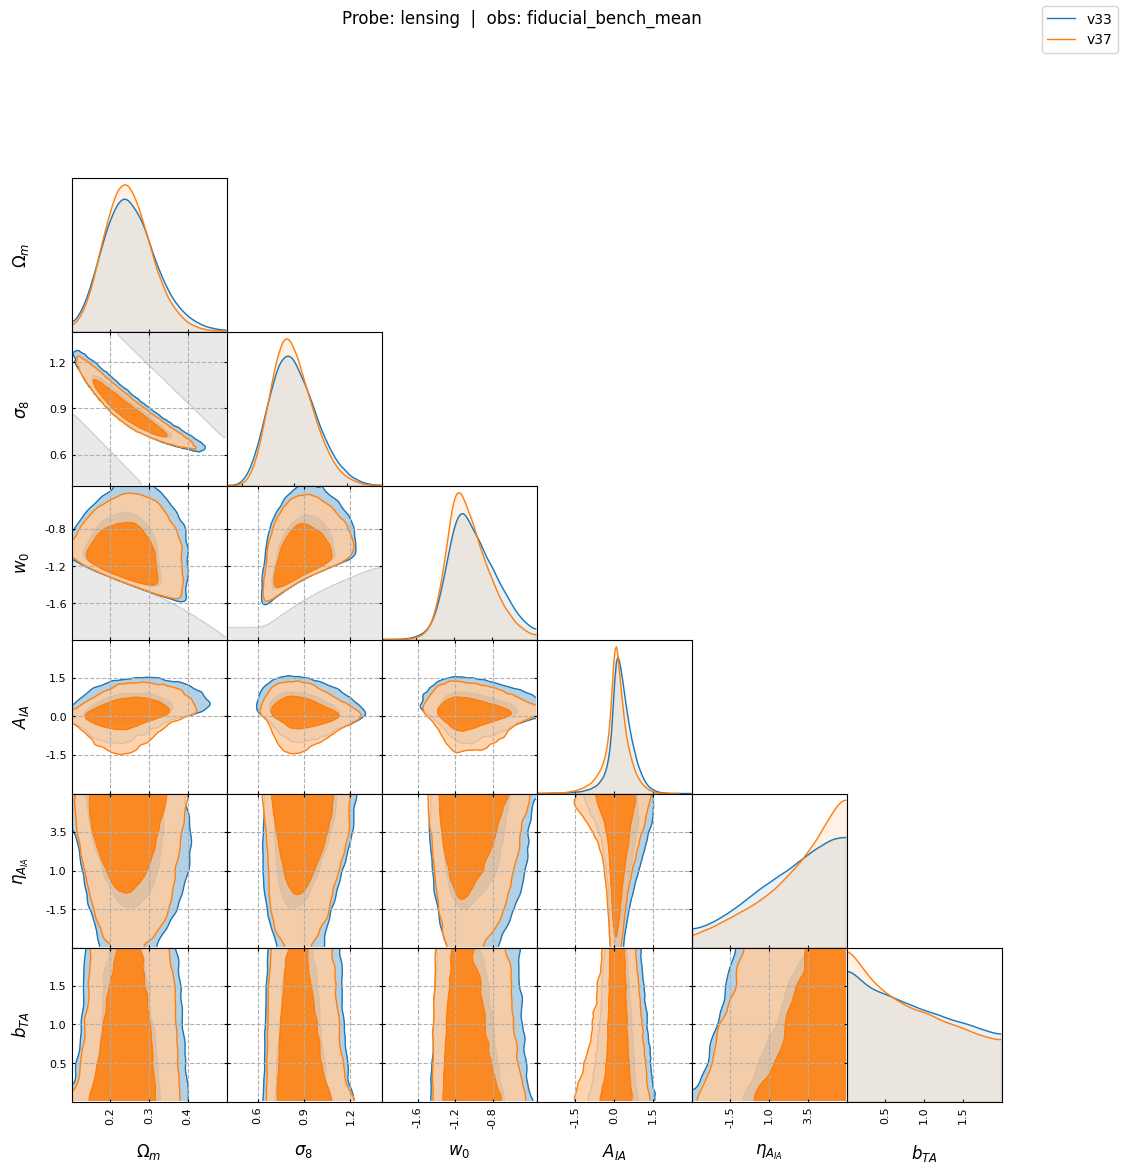

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v37/ensemble_flow_1000000
26-06-30 13:00:16     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:00:18  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_lensing_grid_(1,64,0).png 


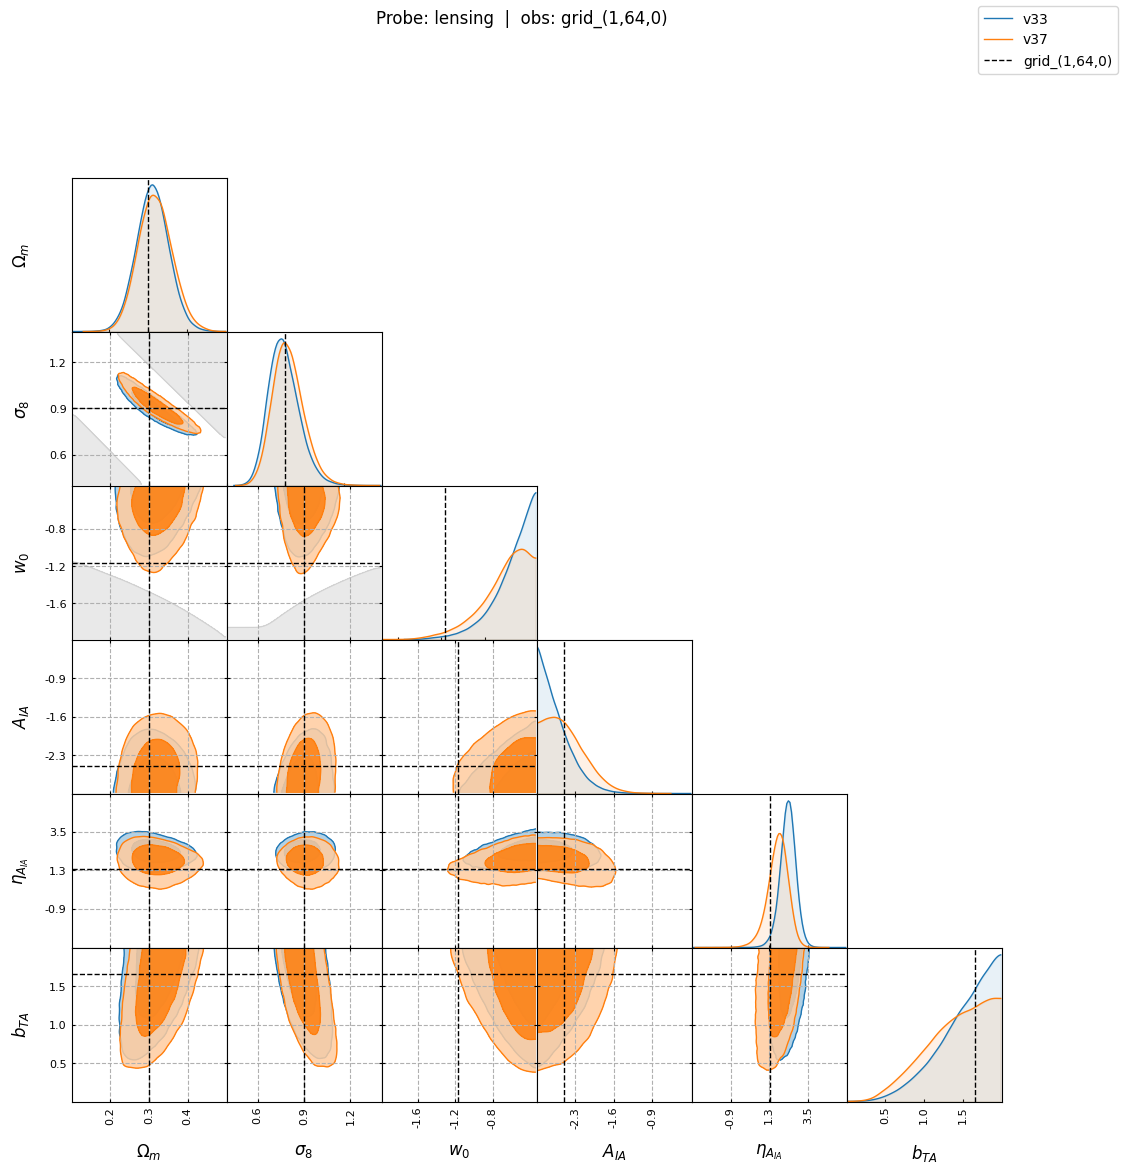

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v37/ensemble_flow_1000000
26-06-30 13:00:23     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:00:24  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_lensing_grid_(2,64,0).png 


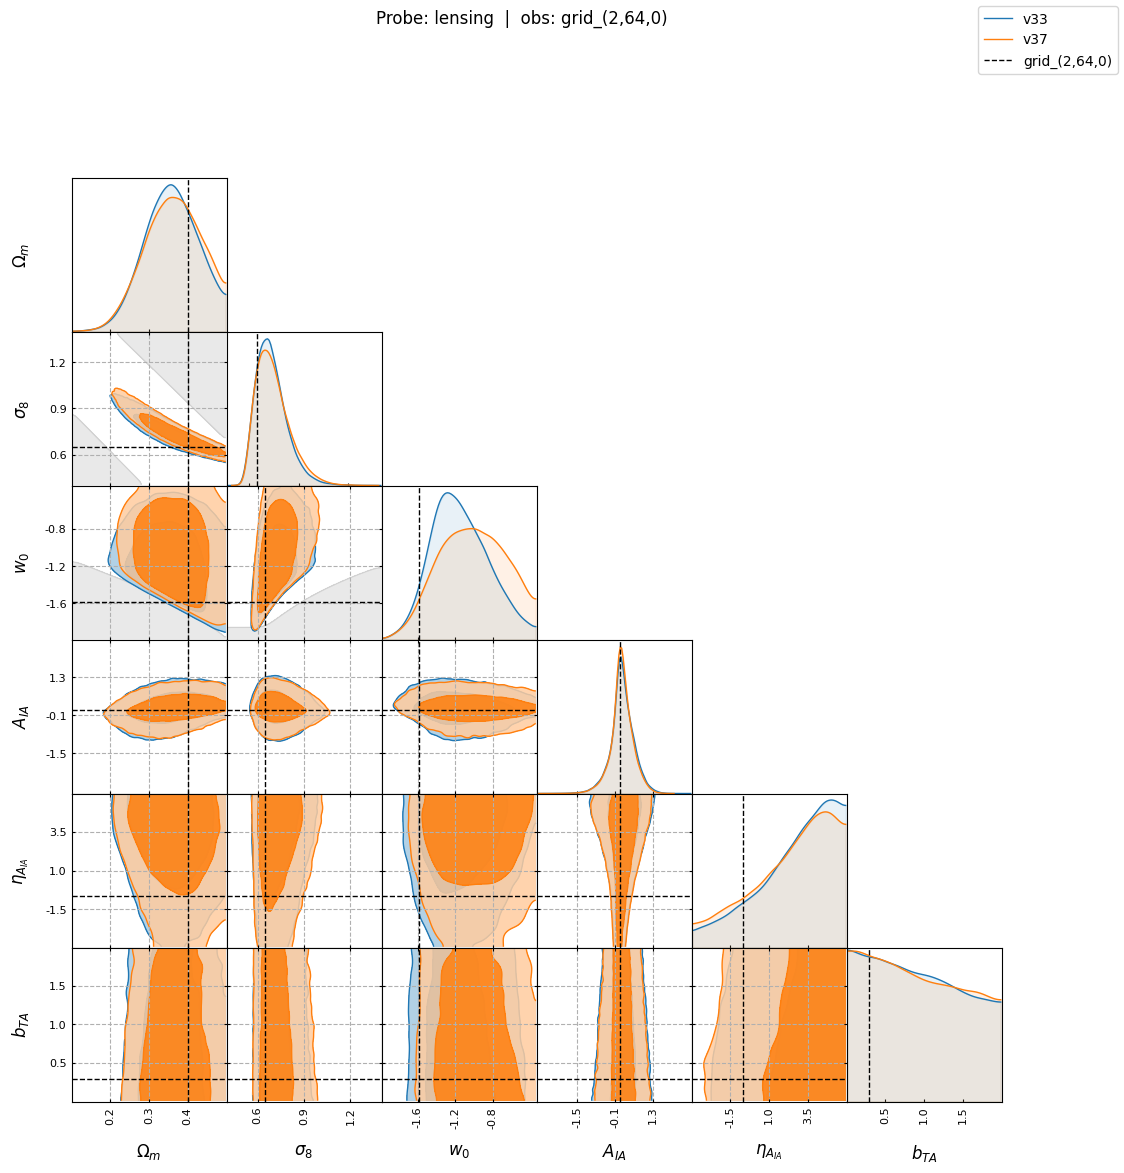

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v37/ensemble_flow_1000000
26-06-30 13:00:29     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:00:30  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_lensing_grid_(3,64,0).png 


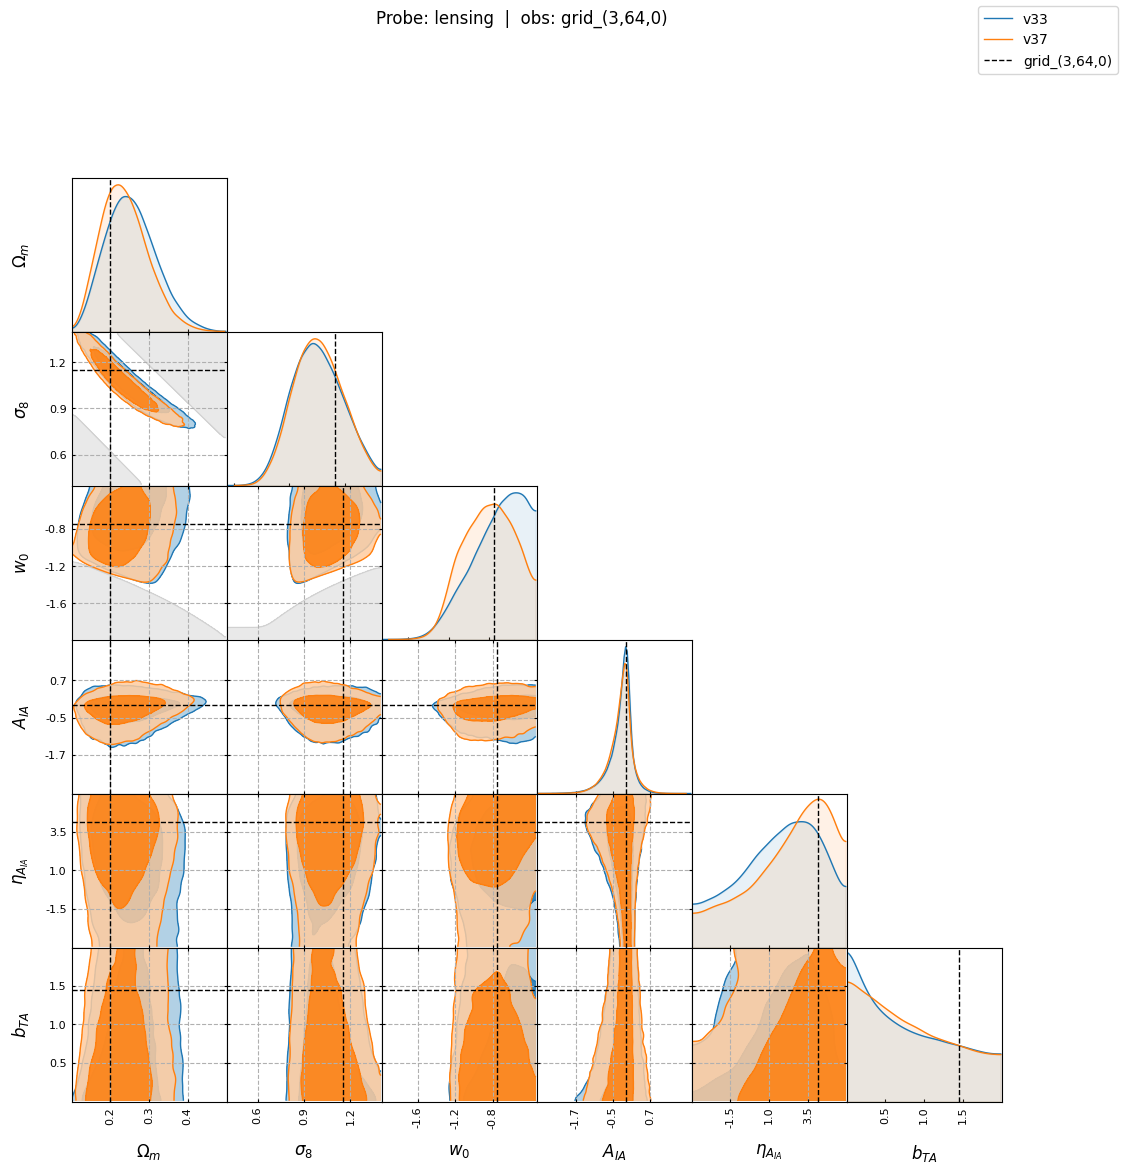

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v37/ensemble_flow_1000000
26-06-30 13:00:35     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:00:36  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_lensing_grid_(4,64,0).png 


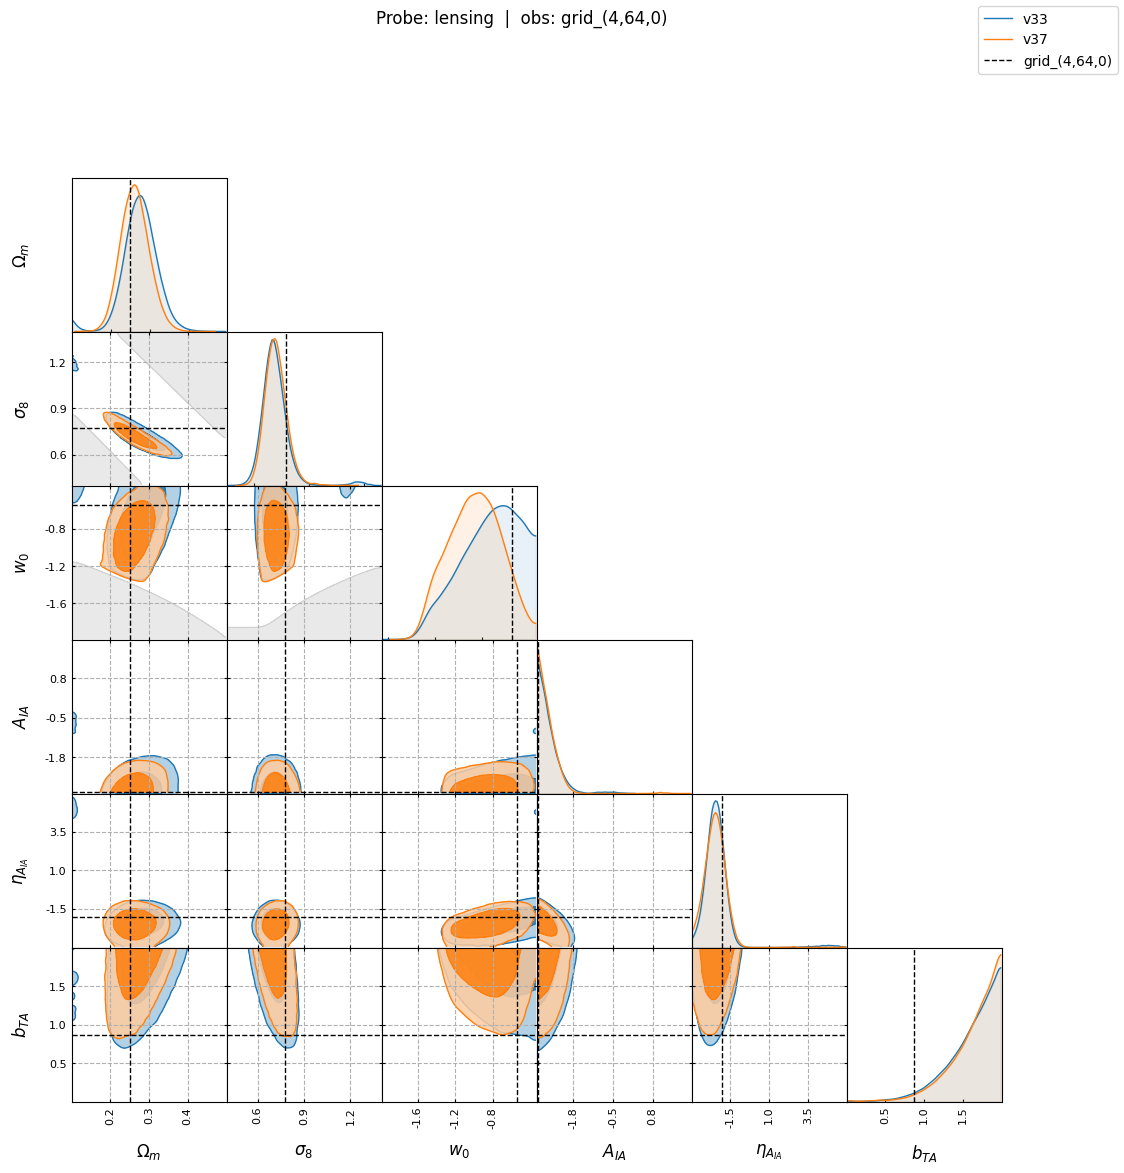

26-06-30 13:00:37 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v33/preds_1000000.h5 
26-06-30 13:00:37 input_output INF   grid_preds.shape = (200000, 7) 
26-06-30 13:00:37 input_output INF   grid_cosmos.shape = (200000, 7) 
26-06-30 13:00:37 input_output INF   DESy3 with shape (7,) 
26-06-30 13:00:37 input_output INF   DESy3_no_sys with shape (7,) 
26-06-30 13:00:37 input_output INF   fiducial_bench_mean with shape (7,) 
26-06-30 13:00:37 input_output INF   fiducial_bench_stack with shape (80, 7) 
26-06-30 13:00:37 input_output INF   grid_(1,64,0) with shape (7,) 
26-06-30 13:00:37 input_output INF   grid_(2,64,0) with shape (7,) 
26-06-30 13:00:37 input_output INF   grid_(3,64,0) with shape (7,) 
26-06-30 13:00:37 input_output INF   grid_(4,64,0) with shape (7,) 
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/a

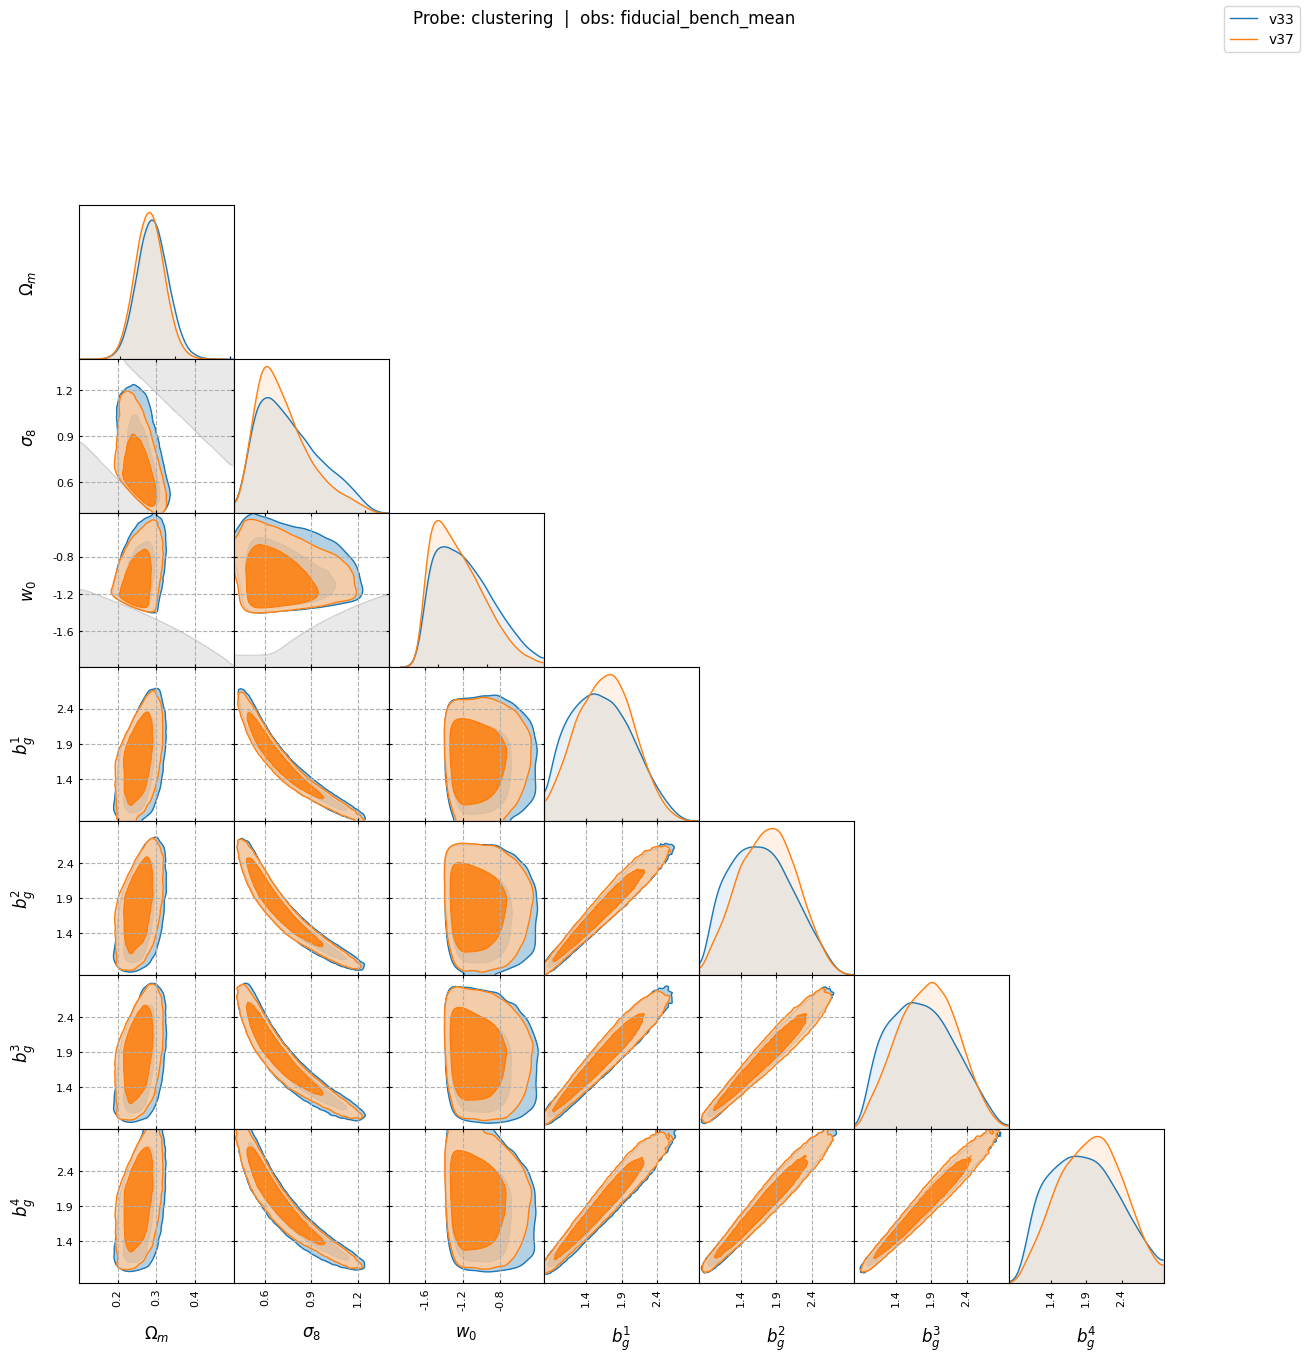

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v37/ensemble_flow_1000000
26-06-30 13:00:50     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:00:52  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_clustering_grid_(1,64,0).png 


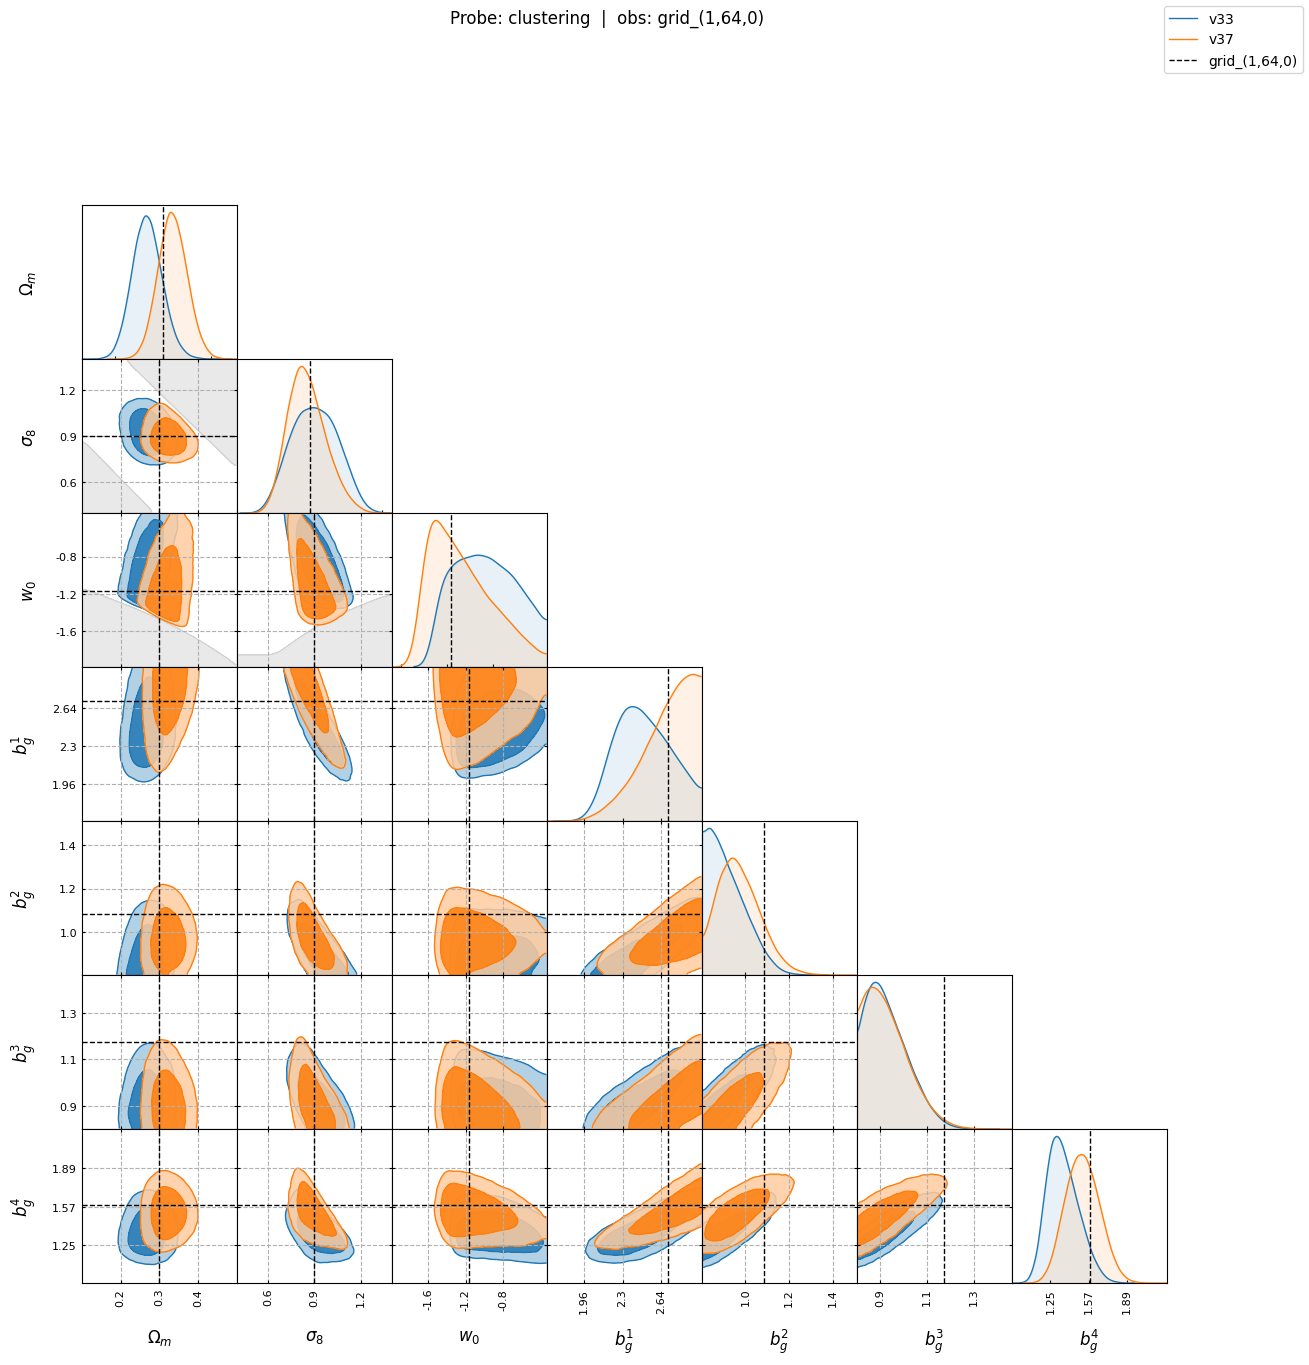

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v37/ensemble_flow_1000000
26-06-30 13:00:58     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:01:00  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_clustering_grid_(2,64,0).png 


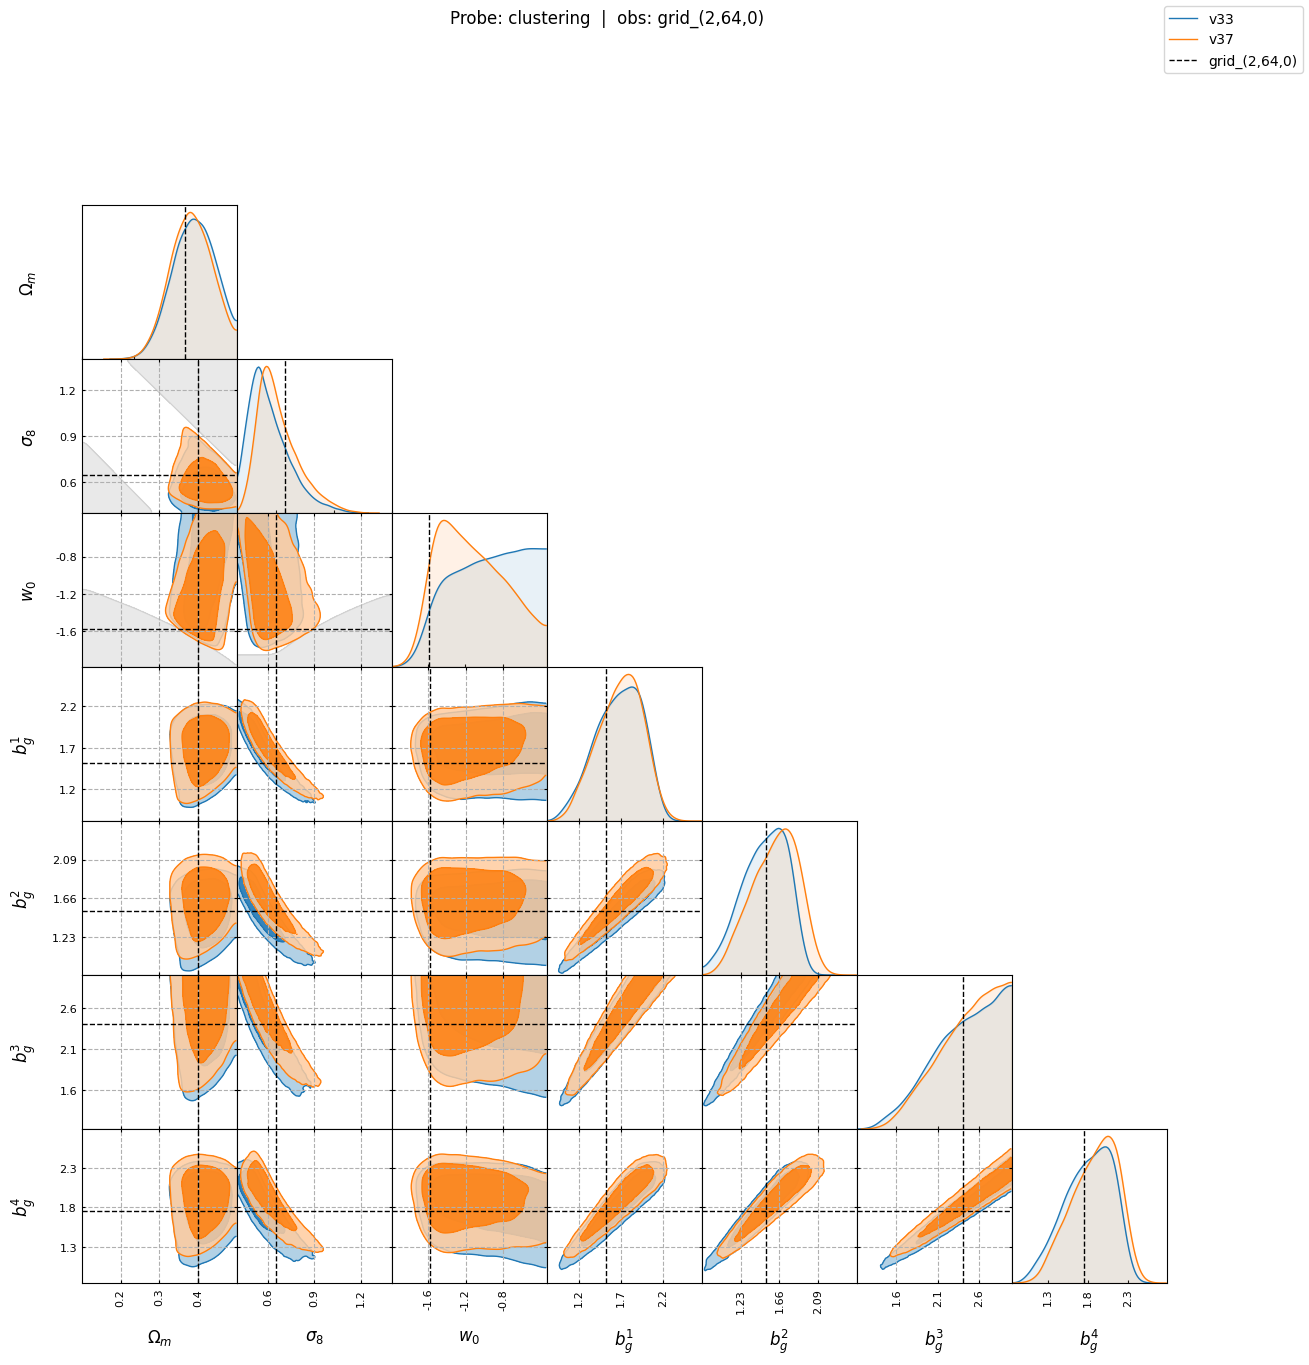

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v37/ensemble_flow_1000000
26-06-30 13:01:06     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:01:07  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_clustering_grid_(3,64,0).png 


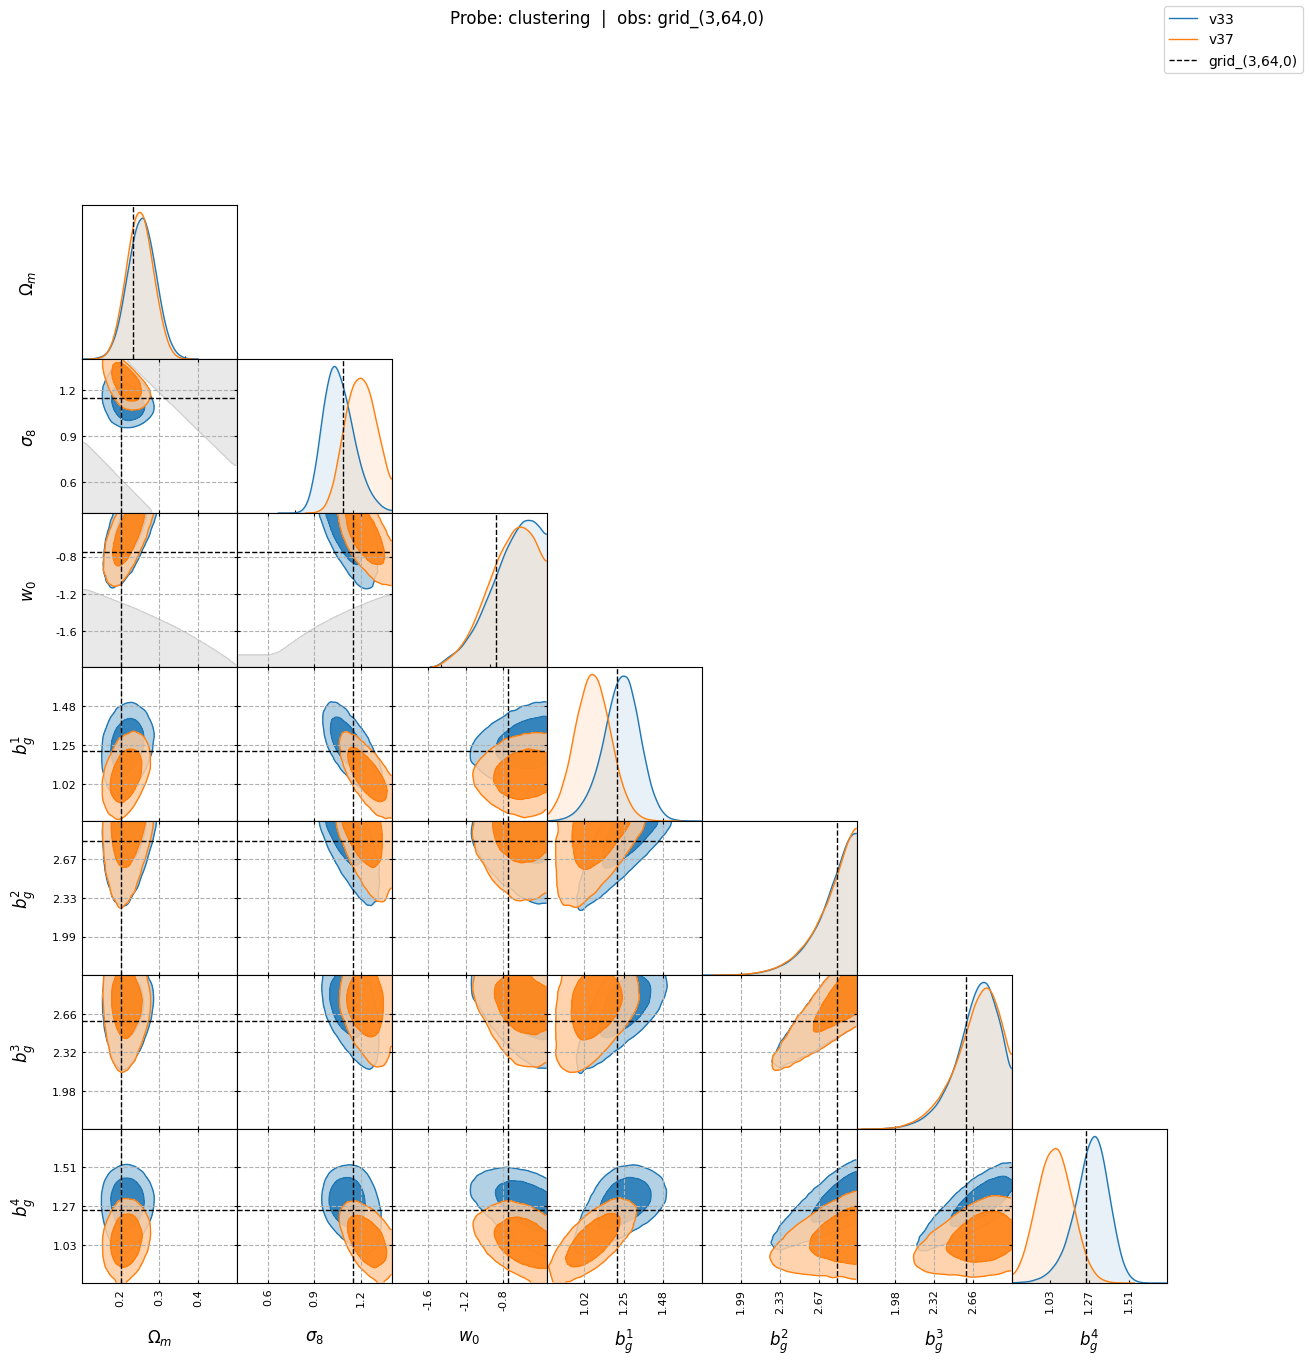

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/clustering/v37/ensemble_flow_1000000
26-06-30 13:01:13     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:01:15  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_clustering_grid_(4,64,0).png 


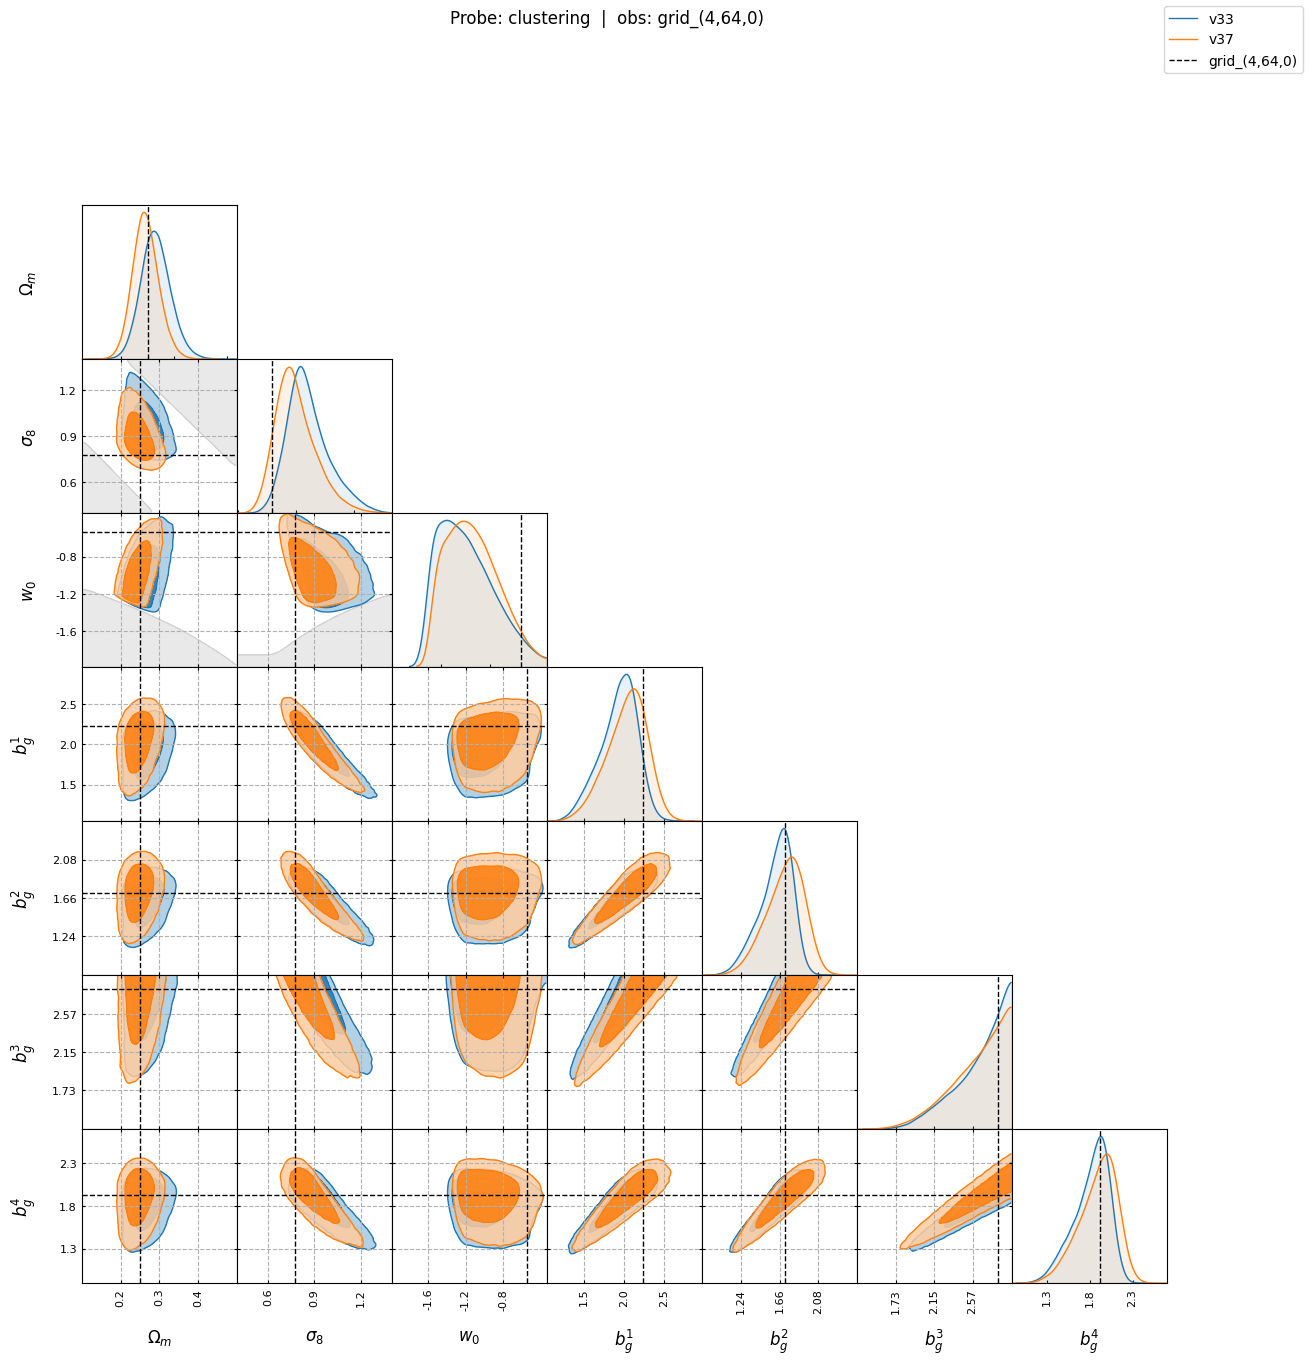

26-06-30 13:01:15 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/combined/v33/preds_1000000.h5 
26-06-30 13:01:15 input_output INF   grid_preds.shape = (200000, 10) 
26-06-30 13:01:15 input_output INF   grid_cosmos.shape = (200000, 10) 
26-06-30 13:01:15 input_output INF   DESy3 with shape (10,) 
26-06-30 13:01:15 input_output INF   DESy3_no_psi_rot with shape (10,) 
26-06-30 13:01:15 input_output INF   DESy3_no_sys with shape (10,) 
26-06-30 13:01:15 input_output INF   DESy3_no_sys_no_psi_rot with shape (10,) 
26-06-30 13:01:15 input_output INF   fiducial_bench_mean with shape (10,) 
26-06-30 13:01:15 input_output INF   fiducial_bench_stack with shape (80, 10) 
26-06-30 13:01:15 input_output INF   grid_(1,64,0) with shape (10,) 
26-06-30 13:01:15 input_output INF   grid_(2,64,0) with shape (10,) 
26-06-30 13:01:15 input_output INF   grid_(3,64,0) with shape (10,) 
26-06-30 13:01:15 input_output INF   grid_(4,64,0) with sh

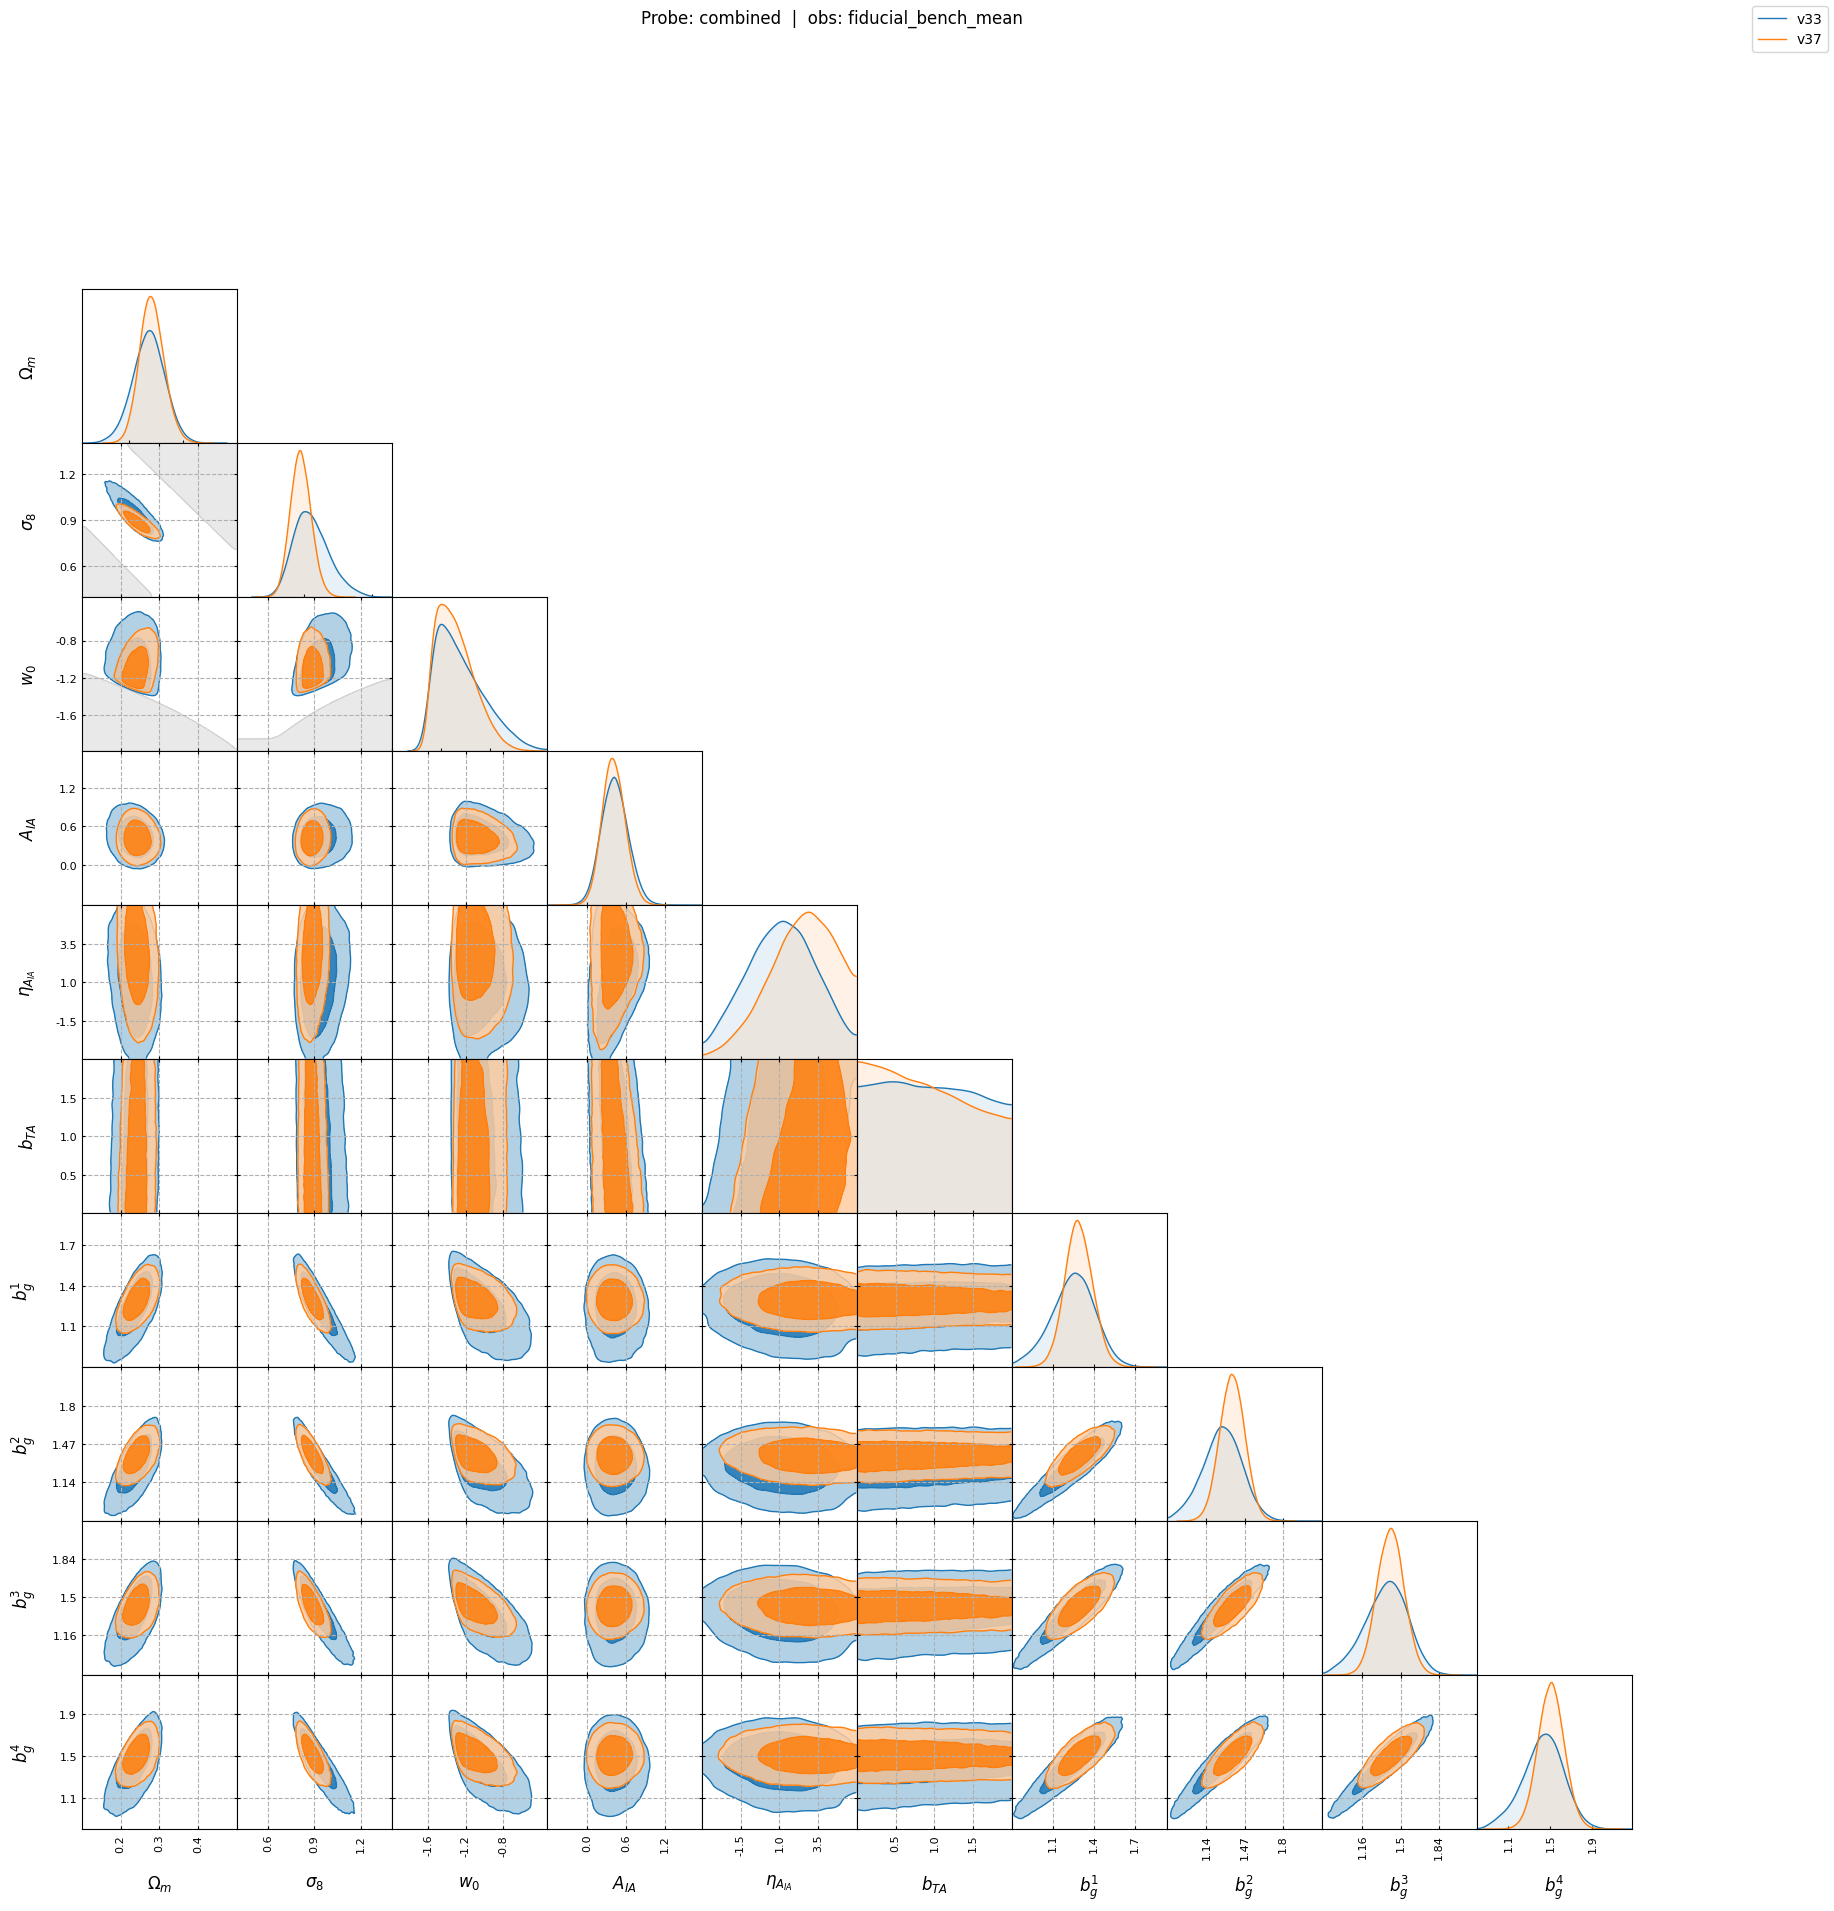

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/combined/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/combined/v37/ensemble_flow_1000000
26-06-30 13:01:40     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:01:43  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_combined_grid_(1,64,0).png 


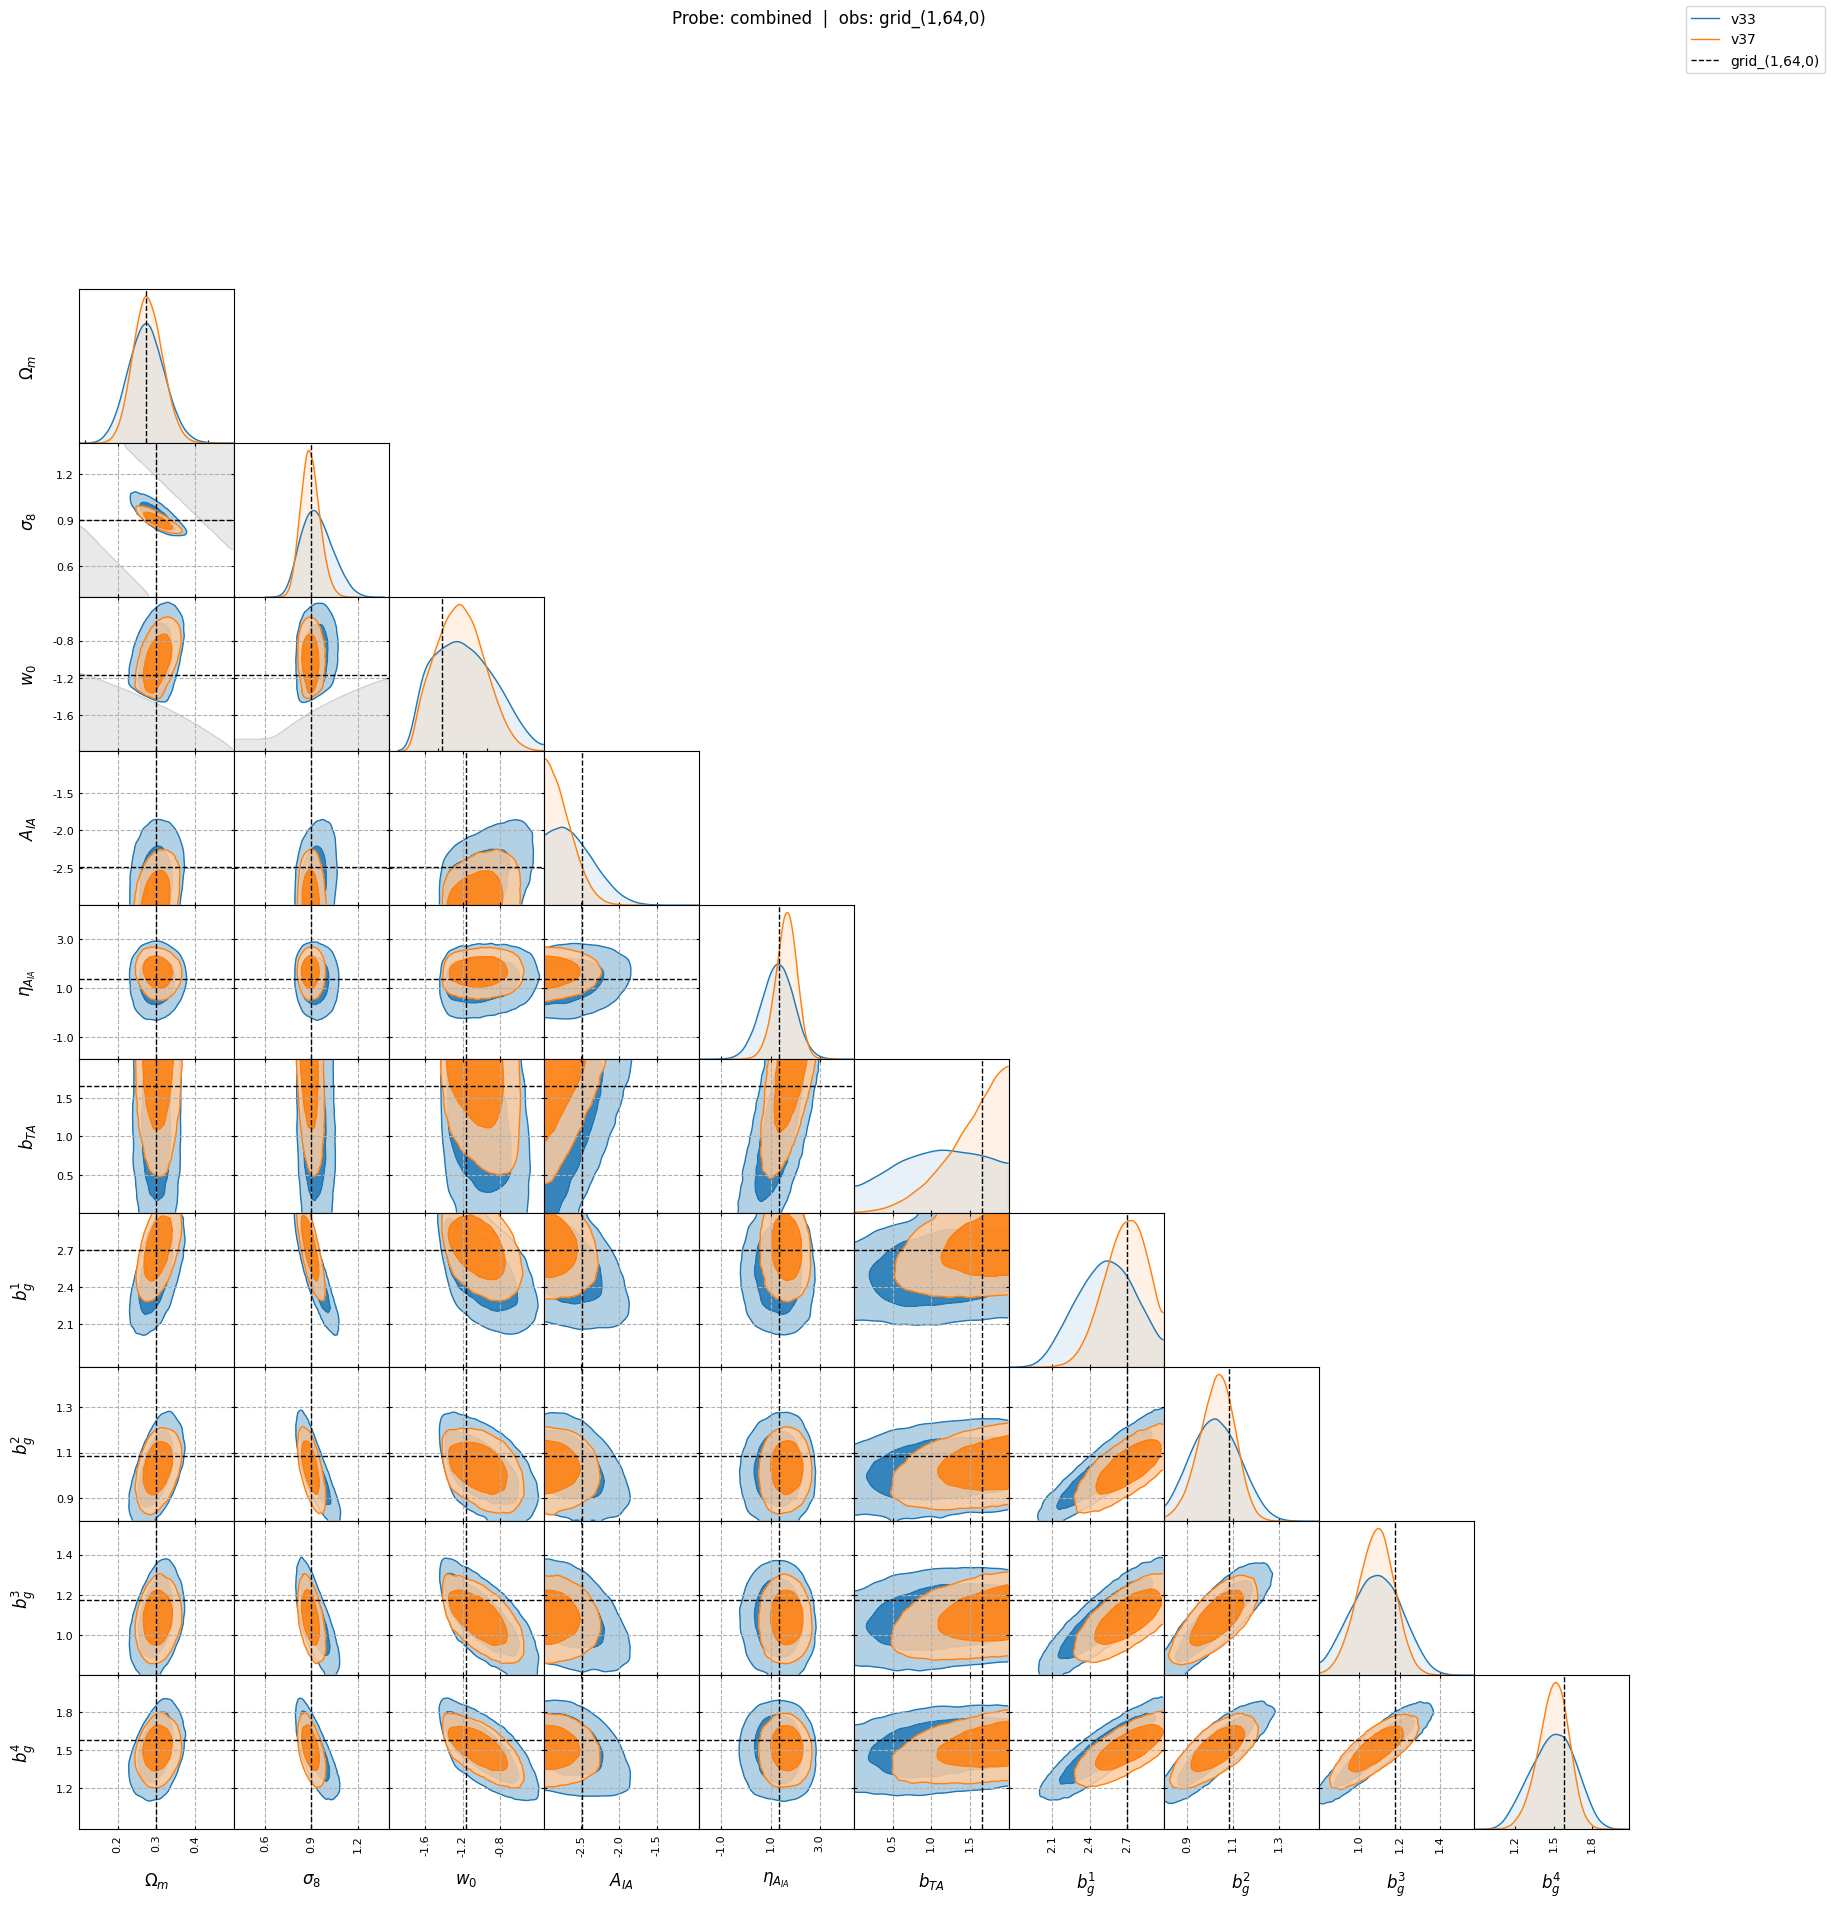

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/combined/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/combined/v37/ensemble_flow_1000000
26-06-30 13:01:55     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:01:57  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_combined_grid_(2,64,0).png 


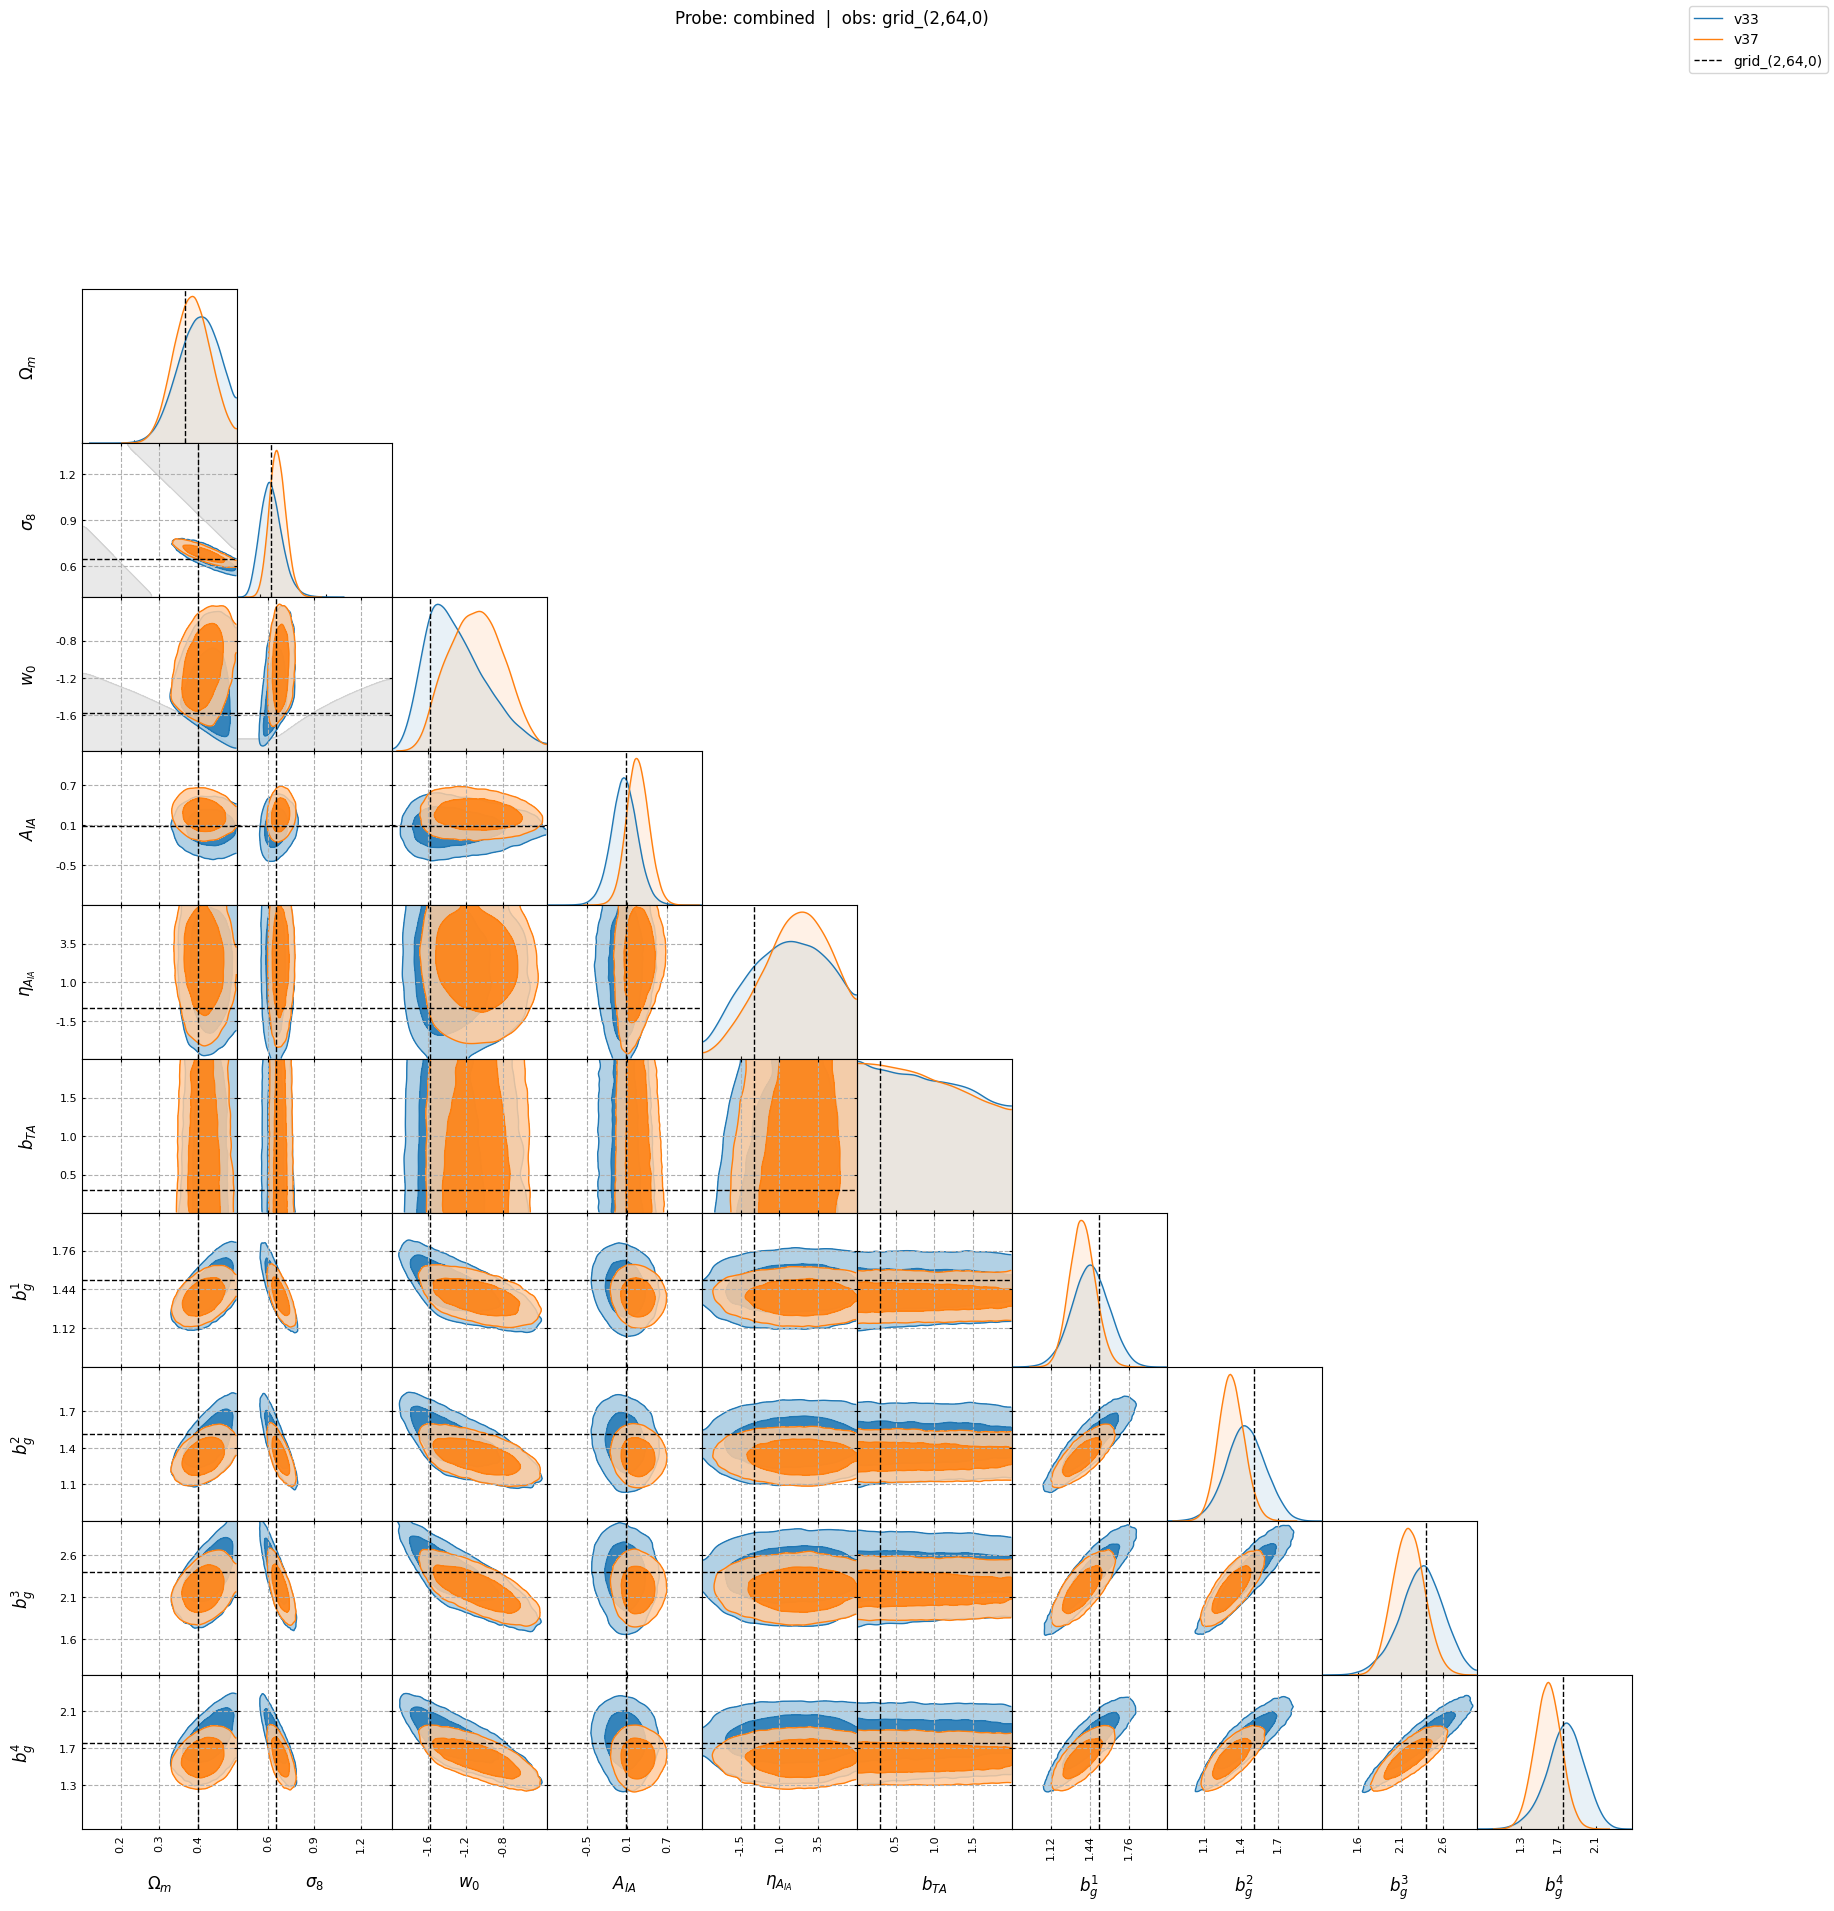

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/combined/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/combined/v37/ensemble_flow_1000000
26-06-30 13:02:09     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:02:11  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_combined_grid_(3,64,0).png 


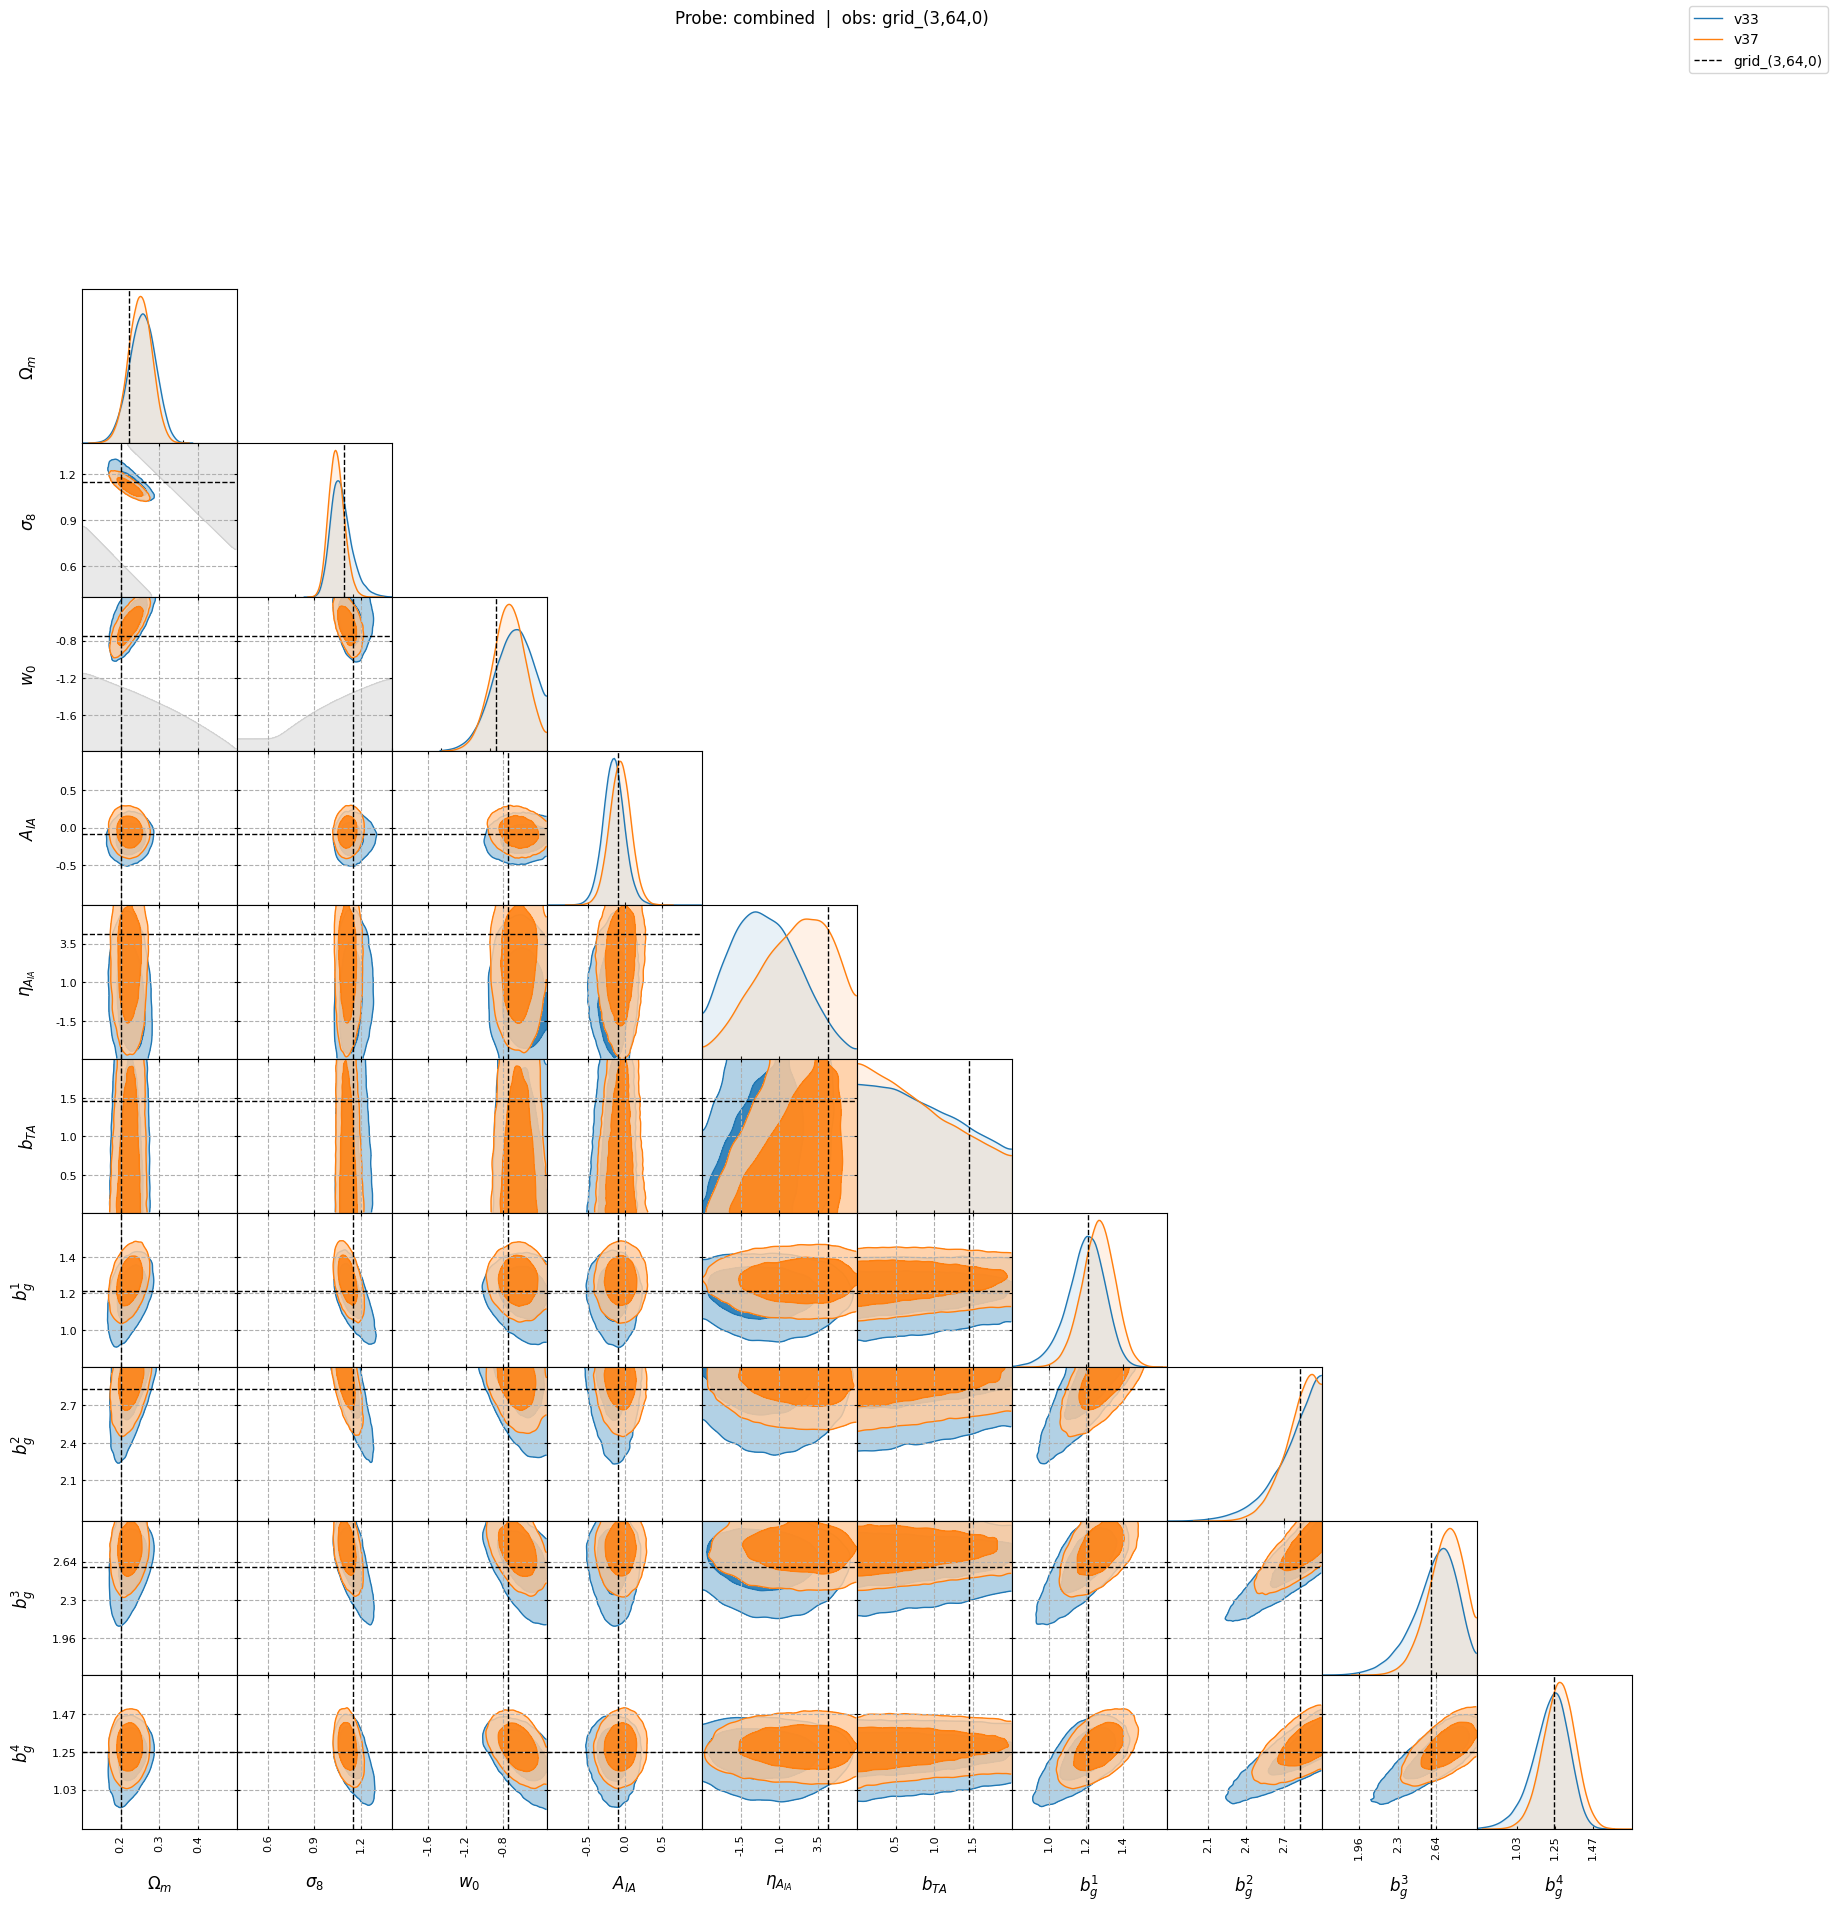

Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/combined/v33/ensemble_flow_1000000
Flow dir: /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/combined/v37/ensemble_flow_1000000
26-06-30 13:02:23     prior.py INF   Generated 3841699 randoms in prior 
26-06-30 13:02:25  plotting.py INF   Saved the plot to plots/cls_v33_vs_v37/contours_combined_grid_(4,64,0).png 


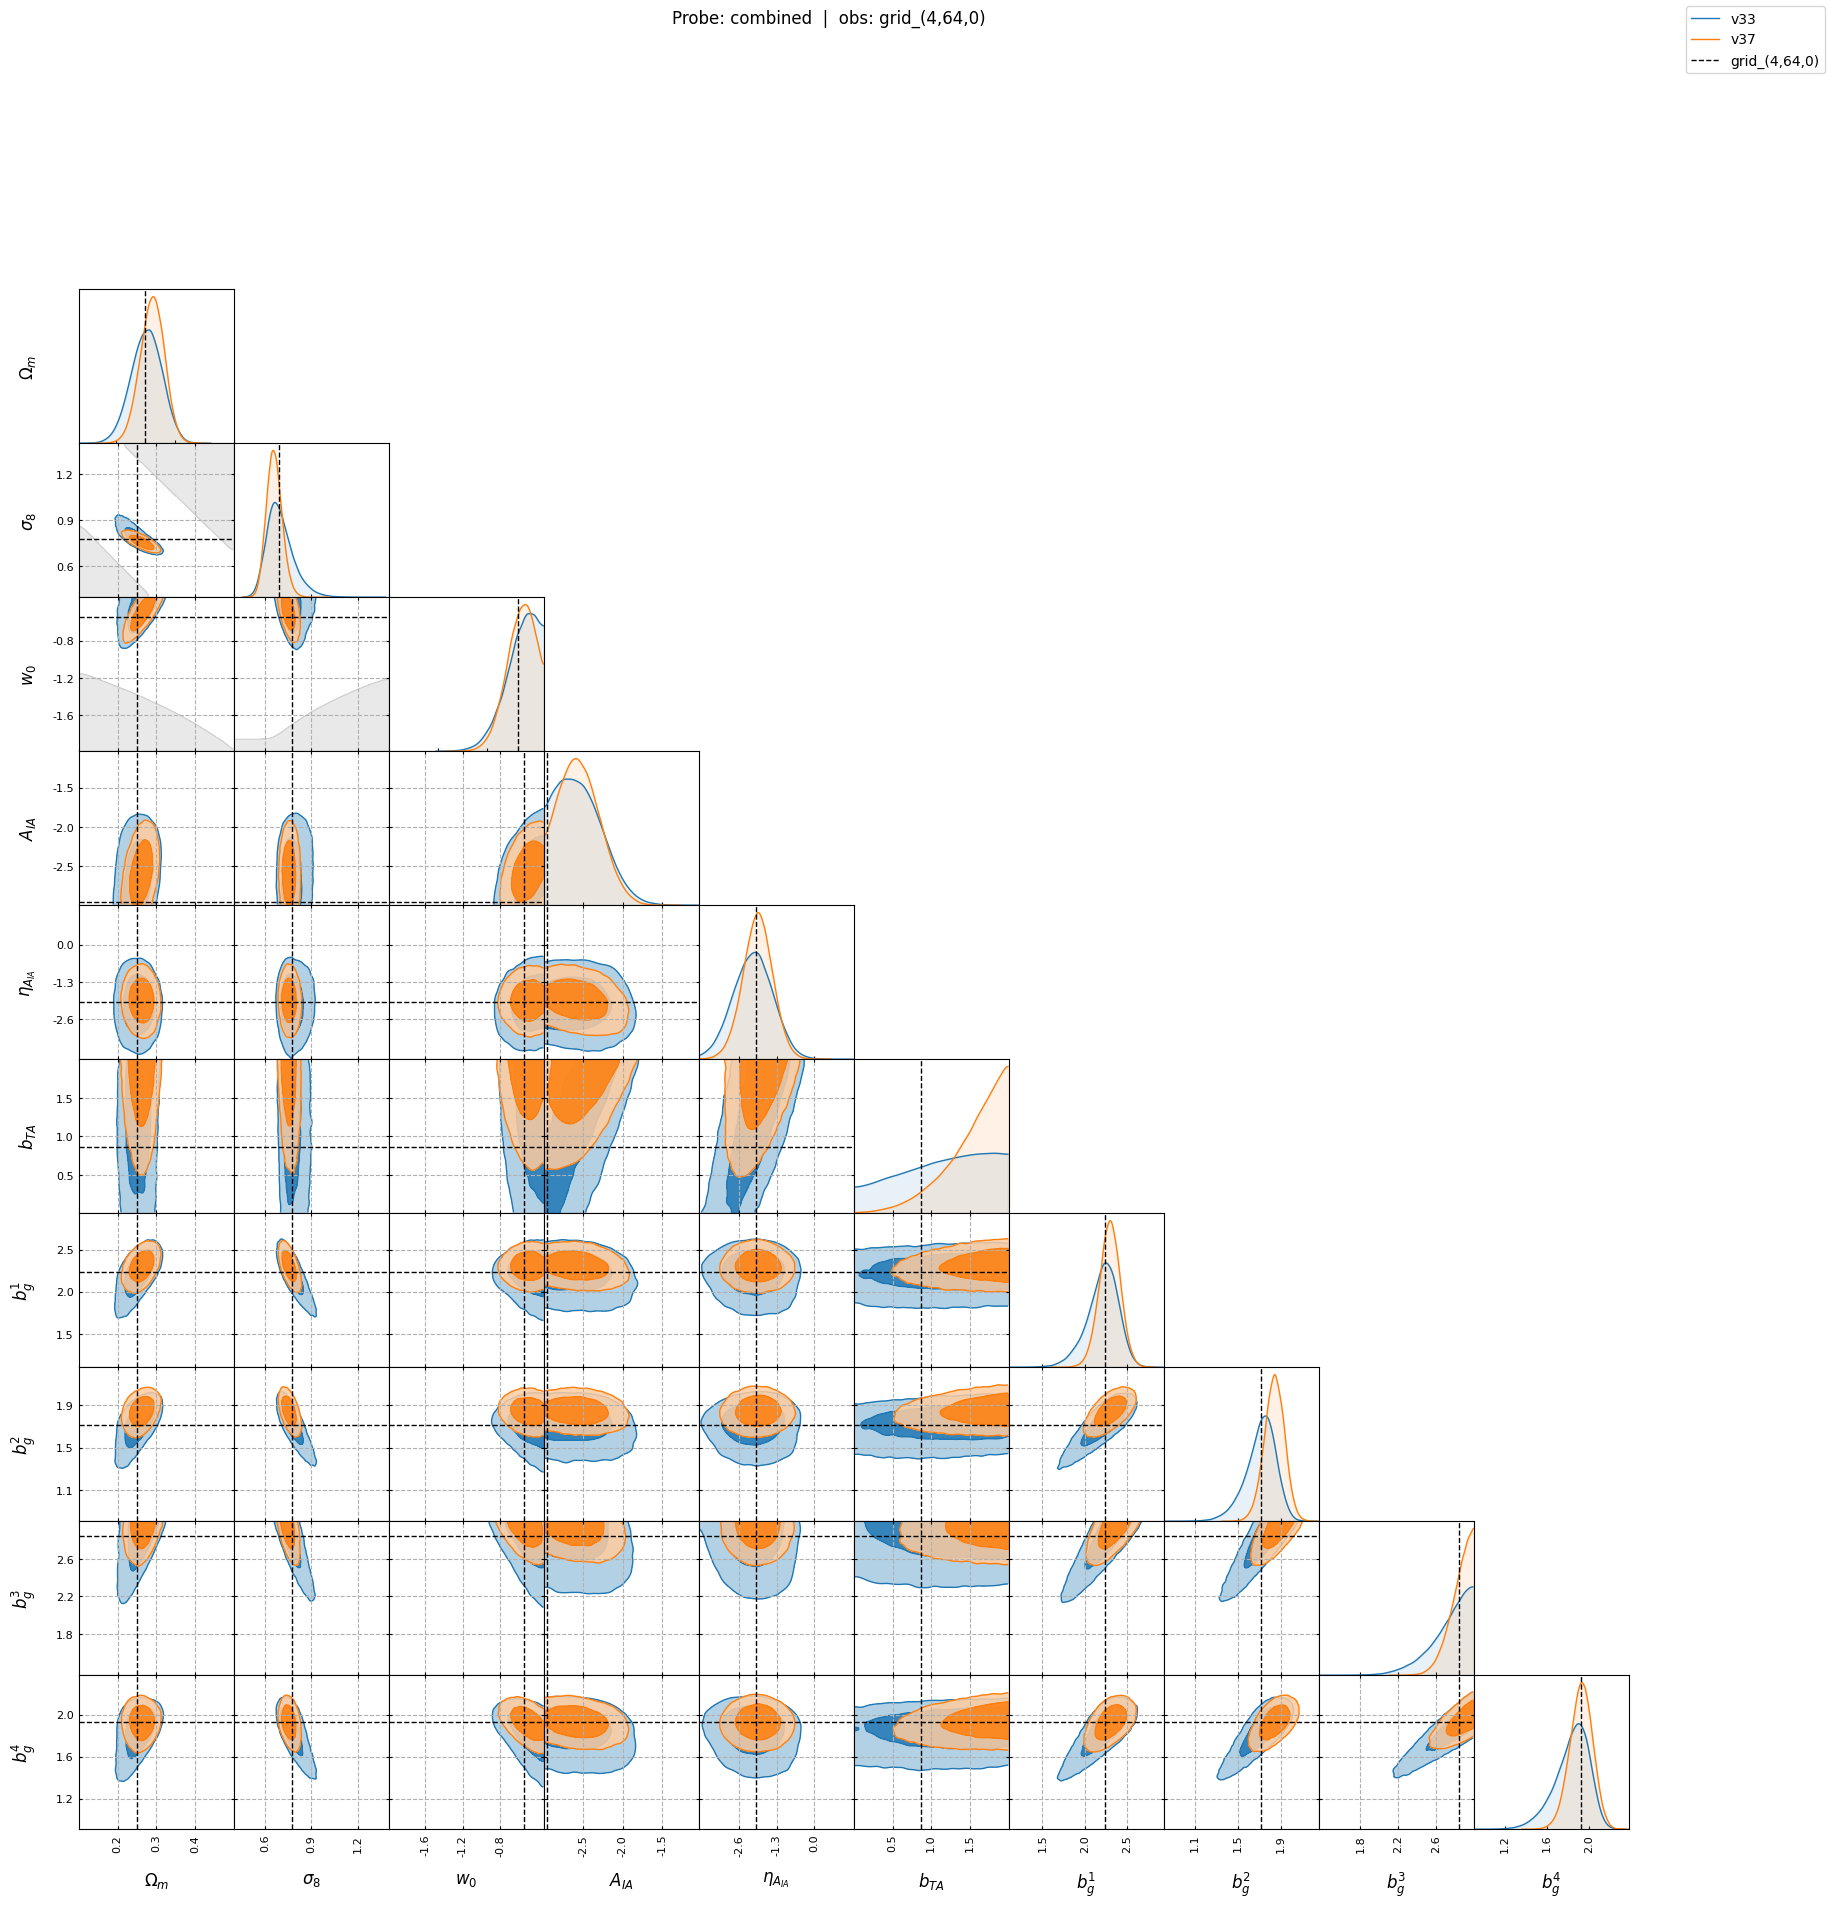

In [84]:
probe_groups = defaultdict(list)
for run in runs:
    probe_groups[run["probe"]].append(run)

for probe, probe_runs in probe_groups.items():
    params = params_by_probe[probe]
    colors = color_palette("tab10", len(probe_runs))

    obs_cosmo_dict = None
    for run in probe_runs:
        pred_path = get_pred_path(run)
        if os.path.exists(pred_path):
            _, _, _, obs_cosmo_dict = input_output.load_network_preds_simple(pred_path)
            break

    flow_dirs = [get_flow_dir(r) for r in probe_runs]
    obs_labels = get_common_chain_labels(flow_dirs)

    for obs_label in obs_labels:
        chains, plot_labels, valid_colors = [], [], []
        for run, color in zip(probe_runs, colors):
            chain_path = os.path.join(get_flow_dir(run), f"chain_{obs_label}.npy")
            if os.path.exists(chain_path):
                chains.append(np.load(chain_path))
                plot_labels.append(run["label"])
                valid_colors.append(color)

        obs_cosmo = None
        if obs_cosmo_dict is not None and obs_label in obs_cosmo_dict:
            obs_cosmo = dict(zip(params, obs_cosmo_dict[obs_label]))

        plotting.plot_chains(
            chains=chains,
            params=params,
            conf=msfm_conf,
            colors=valid_colors,
            plot_labels=plot_labels,
            obs_cosmo=obs_cosmo,
            obs_label=obs_label,
            use_S8=False,
            scale_to_prior=False,
            include_prior=True,
            show_legend=True,
            out_dir=plots_dir,
            file_label=f"{probe}_{obs_label}",
        )
        plt.suptitle(f"Probe: {probe}  |  obs: {obs_label}", y=1.02)
        plt.show()
